Calculating Expected Loss 

- **probability of default (PD) * Loss given default (LGD) * Exposure at default (EAD)**
- establish dependant variable ie what to predict - default or non default
- default definition - eg payment 90 days overdue, fraud
- new variable - 1 default, 0 non default
- Logistic regression where the dependant var is whether the customer defaulted or  not, estimates the relationship between two things.
- Outcome of interest is the non default or default event
- Odds ratio = ratio of non defaults to defaults
- All independent variables should be dummy variables/binary categorical variables or indicator variables
- Transform continous variables to dummy variables
- The greater the value of independent variable the lower the probability of default
- **Fine classing** - turning continous variables into categories
- Weight of evidence (WoE) - shows to what extend an independent variable will predict a dependant variable
   - The formula of the weight of evidence is the natural logarithm of the ratio of the proportion of observations of the first type of outcome of the dependent variable that fall into the respective category of the independent variable and the proportion of observations of the second type of outcome of the dependent variable that fall into the respective category of the independent variable.
   - The two types of outcome are non defaulted or good and defaulted or bad. So the weight of evidence would be the natural logarithm of the ratio of the proportion of goods from the total number of goods that fall into the category to the proportion of bads from the total number of bads that fall into a category.
   - WoE tells us: How strongly a category is associated with: Good loans vs Bad loans - It measures how powerful each category is at separating good and bad borrowers.
- **Course classing** - constructing new catgeories based on the intitial ones. Categories with similar WoE are bundled together which lowers the number of dummies hence improving the pd model
- Information value used for var selection, preselect predictors  - how much information the original dependant variable brings with respect to explaining the dependant variable IV < 0.02 no predictive power, 0.02 < IV < 0.1 weak power, 0.1 <IV 0.3 medium power, 01. <IV <0.5 strong, 0,5 < IV suspiciously high too good to be true 

## PD model

### Data preparation

**Dependant variable : Good/bad (default) Definition default and non default accounts**

#### Import libraries and data 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#display all columns 
pd.options.display.max_columns = None

In [3]:
# Load the file
loan_data = pd.read_parquet('loan_data_cleaned.parquet')

In [4]:
loan_data.columns.values

array(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
       'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
       'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'veri

In [5]:
loan_data.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,term_int,earliest_cr_line_date,days_since_earliest_cr_line,mths_since_earliest_cr_line,issue_d_date,days_since_issue_d,mths_since_issue_d,grade : A,grade : B,grade : C,grade : D,grade : E,grade : F,grade : G,sub_grade : A1,sub_grade : A2,sub_grade : A3,sub_grade : A4,sub_grade : A5,sub_grade : B1,sub_grade : B2,sub_grade : B3,sub_grade : B4,sub_grade : B5,sub_grade : C1,sub_grade : C2,sub_grade : C3,sub_grade : C4,sub_grade : C5,sub_grade : D1,sub_grade : D2,sub_grade : D3,sub_grade : D4,sub_grade : D5,sub_grade : E1,sub_grade : E2,sub_grade : E3,sub_grade : E4,sub_grade : E5,sub_grade : F1,sub_grade : F2,sub_grade : F3,sub_grade : F4,sub_grade : F5,sub_grade : G1,sub_grade : G2,sub_grade : G3,sub_grade : G4,sub_grade : G5,home_ownership : ANY,home_ownership : MORTGAGE,home_ownership : NONE,home_ownership : OTHER,home_ownership : OWN,home_ownership : RENT,verification_status : Not Verified,verification_status : Source Verified,verification_status : Verified,loan_status : Charged Off,loan_status : Current,loan_status : Default,loan_status : Does not meet the credit policy. Status:Charged Off,loan_status : Does not meet the credit policy. Status:Fully Paid,loan_status : Fully Paid,loan_status : In Grace Period,loan_status : Late (16-30 days),loan_status : Late (31-120 days),purpose : car,purpose : credit_card,purpose : debt_consolidation,purpose : educational,purpose : home_improvement,purpose : house,purpose : major_purchase,purpose : medical,purpose : moving,purpose : other,purpose : renewable_energy,purpose : small_business,purpose : vacation,purpose : wedding,addr_state : AK,addr_state : AL,addr_state : AR,addr_state : AZ,addr_state : CA,addr_state : CO,addr_state : CT,addr_state : DC,addr_state : DE,addr_state : FL,addr_state : GA,addr_state : HI,addr_state : IA,addr_state : ID,addr_state : IL,addr_state : IN,addr_state : KS,addr_state : KY,addr_state : LA,addr_state : MA,addr_state : MD,addr_state : ME,addr_state : MI,addr_state : MN,addr_state : MO,addr_state : MS,addr_state : MT,addr_state : NC,addr_state : NE,addr_state : NH,addr_state : NJ,addr_state : NM,addr_state : NV,addr_state : NY,addr_state : OH,addr_state : OK,addr_state : OR,addr_state : PA,addr_state : RI,addr_state : SC,addr_state : SD,addr_state : TN,addr_state : TX,addr_state : UT,addr_state : VA,addr_state : VT,addr_state : WA,addr_state : WI,addr_state : WV,addr_state : WY,initial_list_status : f,initial_list_status : w
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,None,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,None,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.0,NaN,NaN,NaN,10.0,36,1985-01-01,12022 days,395,2011-12-01,2192 days,72,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0

#### Default and non default flag - dependant/target variable y

In [6]:
#data about borrower perfomance and repayment behaviour
loan_data ['loan_status'].unique()

array(['Fully Paid', 'Charged Off', 'Current', 'Default',
       'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [7]:
#see how many values are there for each status
loan_data['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [8]:
#see proportion of accounts by status
loan_data ['loan_status'].value_counts() / loan_data['loan_status'].count()

loan_status
Current                                                0.480878
Fully Paid                                             0.396193
Charged Off                                            0.091092
Late (31-120 days)                                     0.014798
In Grace Period                                        0.006747
Does not meet the credit policy. Status:Fully Paid     0.004263
Late (16-30 days)                                      0.002612
Default                                                0.001784
Does not meet the credit policy. Status:Charged Off    0.001632
Name: count, dtype: float64

In [9]:
# #store good/bad flag or default 0 /non default 1 indicators
# # We create a new variable that has the value of '0' if a condition is met, and the value of '1' if it is not met.
# loan_data['good_bad'] = np.where(loan_data['loan_status'].isin(['Charged Off', 'Default',
#                                                        'Does not meet the credit policy. Status:Charged Off',
#                                                        'Late (31-120 days)']), 0, 1) 

In [10]:
#creating the dependant variable Y
#target/label engineering - define default 
default_statuses = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off',
    'Late (31-120 days)'
]

loan_data['good_bad'] = (~loan_data['loan_status'].isin(default_statuses)).astype(int)

In [11]:
loan_data['good_bad']

0         1
1         0
2         1
3         1
4         1
         ..
466280    1
466281    0
466282    1
466283    1
466284    1
Name: good_bad, Length: 466285, dtype: int64

#### Constructing independent variables X (features/predictors)

#### Splitting data - solution to overfitting

In [12]:
# Takes a set of inputs and a set of targets as arguments. Splits the inputs and the targets into four dataframes:
# Inputs - Train, Inputs - Test, Targets - Train, Targets - Test
# axis=0 means "Look at the rows" (top to bottom).
# axis=1 means "Look at the columns" (left to right).
# This is identical to using axis=1 and is harder to mess up:
# loan_data.drop(columns=['good_bad'])
# train_test_split(loan_data.drop('good_bad', axis = 1), loan_data['good_bad']) #Find the column named 'good_bad' and remove it from the side of the table."

In [13]:
train_test_split(
    loan_data.drop(columns='good_bad'), 
    loan_data['good_bad']
)

[        Unnamed: 0        id  member_id  loan_amnt  funded_amnt  \
 150707      150707   4175943    5318210      17000        17000   
 356916      356916  20139931   22402511      15000        15000   
 157699      157699   3666024    4629140       8400         8400   
 463161      463161  10170045   12021594      12800        12800   
 322542      322542  24665632   27098562       6000         6000   
 ...            ...       ...        ...        ...          ...   
 443073      443073  11794946   13787086       7200         7200   
 54220        54220   9227993   11049927       6000         6000   
 151433      151433   4115062    5257269      24000        24000   
 351083      351083  20710854   22983406      14000        14000   
 283180      283180  30445940   32999135      15000        15000   
 
         funded_amnt_inv        term  int_rate  installment grade sub_grade  \
 150707          17000.0   36 months     17.77       612.64     D        D1   
 356916          15000.0

In [14]:
# X_train, X_test, y_train, y_test = train_test_split(
#     loan_data.drop(columns='good_bad'), 
#     loan_data['good_bad']
# )

In [15]:
# loan_data_inputs_train, loan_data_inputs_test,loan_data_targets_train, loan_data_targets_test = train_test_split(
#                 loan_data.drop('good_bad', axis = 1), 
#                 loan_data['good_bad']
# )

In [16]:
loan_data_inputs_train, loan_data_inputs_test,loan_data_targets_train, loan_data_targets_test = train_test_split(
                loan_data.drop(columns= 'good_bad'), 
                loan_data['good_bad']
)  #default 75/25 split for sklearn and shuffle = true

In [17]:
loan_data_inputs_train.shape

(349713, 209)

In [18]:
loan_data_targets_train.shape

(349713,)

In [19]:
loan_data_inputs_test.shape

(116572, 209)

In [20]:
loan_data_targets_test.shape

(116572,)

In [21]:
# loan_data_inputs_train, loan_data_inputs_test,loan_data_targets_train, loan_data_targets_test = train_test_split(
#     loan_data.drop(columns='good_bad'), 
#     loan_data['good_bad'], 
#     test_size = 0.2,
#     random_state = 42
# )

In [22]:
loan_data_inputs_train, loan_data_inputs_test,loan_data_targets_train, loan_data_targets_test  = train_test_split(
    loan_data.drop(columns='good_bad'), 
    loan_data['good_bad'],
    test_size=0.2,
    random_state=42,  #shuffling pattern
    stratify=loan_data['good_bad']  #fairness - keep the same Good/Bad ratio.
)

In [23]:
loan_data_inputs_train.shape  #373,028 rows (observations) 209 variables (features)

(373028, 209)

In [24]:
loan_data_targets_train.shape

(373028,)

In [25]:
loan_data_inputs_test.shape

(93257, 209)

In [26]:
loan_data_targets_test.shape

(93257,)

#### Preprocessing discrete values

In [27]:
#independent var are in inputs df and the dependant var are in the target df
df_inputs_prepr = loan_data_inputs_train
df_target_prepr = loan_data_targets_train
# df_inputs_prepr = loan_data_inputs_test
# df_target_prepr = loan_data_targets_test

In [28]:
df_inputs_prepr['grade'].unique()

array(['A', 'D', 'B', 'F', 'C', 'E', 'G'], dtype=object)

In [29]:
#glue the two columns side by side into one small df
df1 = pd.concat([df_inputs_prepr['grade'], df_target_prepr], axis =1)
df1.head()

,grade,good_bad
456615,A,1
451541,D,1
394474,D,1
110294,A,1
139343,B,0


##### WoE for variable grade

In [ ]:
# 1. find proportion of bad and good borrowers by grade
#count no rows that contain each grade using groupby
# parametarize the code to make it reusable
df1.groupby(df1.columns.values[0],  
    as_index= False)[df1.columns.values[1]].count()

,grade,good_bad
0,A,59810
1,B,109344
2,C,100342
3,D,61713
4,E,28590
5,F,10606
6,G,2623


In [31]:
# # Use iloc-style logic to get the names
# col_to_group = df1.columns[0]  
# col_to_count = df1.columns[1]  

# df1.groupby(col_to_group, as_index=False)[col_to_count].count()

In [32]:
#proportion of borrowers in each group by calculating average of good & bad 
df1.groupby(df1.columns.values[0], 
    as_index= False)[df1.columns.values[1]].mean()

,grade,good_bad
0,A,0.961361
1,B,0.921422
2,C,0.885870
3,D,0.845527
4,E,0.804477
5,F,0.758061
6,G,0.721693


In [33]:
#merge
df1 = pd.concat([df1.groupby(df1.columns.values[0], as_index = False)[df1.columns.values[1]].count(),
                df1.groupby(df1.columns.values[0], as_index = False)[df1.columns.values[1]].mean()], axis = 1)
df1

,grade,good_bad,grade,good_bad
0,A,59810,A,0.961361
1,B,109344,B,0.921422
2,C,100342,C,0.885870
3,D,61713,D,0.845527
4,E,28590,E,0.804477
5,F,10606,F,0.758061
6,G,2623,G,0.721693


In [34]:
#return only the grade, good bad count and mean
df1 = df1.iloc[:, [0,1,3]]
df1

,grade,good_bad,good_bad
0,A,59810,0.961361
1,B,109344,0.921422
2,C,100342,0.885870
3,D,61713,0.845527
4,E,28590,0.804477
5,F,10606,0.758061
6,G,2623,0.721693


In [35]:
#rename columns
df1.columns = [df1.columns.values[0], 'n_obs', 'prop_good']
df1

,grade,n_obs,prop_good
0,A,59810,0.961361
1,B,109344,0.921422
2,C,100342,0.885870
3,D,61713,0.845527
4,E,28590,0.804477
5,F,10606,0.758061
6,G,2623,0.721693


In [ ]:
# proportion of observations that fall into each grade
df1['prop_n_obs'] = df1['n_obs'] / df1['n_obs'].sum()
df1

,grade,n_obs,prop_good,prop_n_obs
0,A,59810,0.961361,0.160336
1,B,109344,0.921422,0.293125
2,C,100342,0.885870,0.268993
3,D,61713,0.845527,0.165438
4,E,28590,0.804477,0.076643
5,F,10606,0.758061,0.028432
6,G,2623,0.721693,0.007032


In [37]:
#number of good borrowers and bad borrowers by grade group
# We multiply the values of one column by the values of another column
df1['n_good'] = df1['prop_good'] * df1['n_obs']
df1['n_bad'] = (1 - df1['prop_good']) * df1['n_obs']
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad
0,A,59810,0.961361,0.160336,57499.0,2311.0
1,B,109344,0.921422,0.293125,100752.0,8592.0
2,C,100342,0.885870,0.268993,88890.0,11452.0
3,D,61713,0.845527,0.165438,52180.0,9533.0
4,E,28590,0.804477,0.076643,23000.0,5590.0
5,F,10606,0.758061,0.028432,8040.0,2566.0
6,G,2623,0.721693,0.007032,1893.0,730.0


In [38]:
# calculate % of bad and good borrowers for each grade
df1['prop_n_good'] = df1['n_good'] / df1['n_good'].sum()
df1['prop_n_bad'] = df1['n_bad'] / df1['n_bad'].sum()
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad
0,A,59810,0.961361,0.160336,57499.0,2311.0,0.173057,0.056678
1,B,109344,0.921422,0.293125,100752.0,8592.0,0.303238,0.210723
2,C,100342,0.885870,0.268993,88890.0,11452.0,0.267536,0.280865
3,D,61713,0.845527,0.165438,52180.0,9533.0,0.157049,0.233801
4,E,28590,0.804477,0.076643,23000.0,5590.0,0.069224,0.137097
5,F,10606,0.758061,0.028432,8040.0,2566.0,0.024198,0.062932
6,G,2623,0.721693,0.007032,1893.0,730.0,0.005697,0.017904


In [39]:
#calculate WoE of var grade using the natural algorithm of a number
df1['WoE'] = np.log(df1['prop_n_good'] / df1['prop_n_bad'])
# We take the natural logarithm of a variable and save the result in a nex variable.
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE
0,A,59810,0.961361,0.160336,57499.0,2311.0,0.173057,0.056678,1.116232
1,B,109344,0.921422,0.293125,100752.0,8592.0,0.303238,0.210723,0.363975
2,C,100342,0.885870,0.268993,88890.0,11452.0,0.267536,0.280865,-0.048620
3,D,61713,0.845527,0.165438,52180.0,9533.0,0.157049,0.233801,-0.397915
4,E,28590,0.804477,0.076643,23000.0,5590.0,0.069224,0.137097,-0.683340
5,F,10606,0.758061,0.028432,8040.0,2566.0,0.024198,0.062932,-0.955774
6,G,2623,0.721693,0.007032,1893.0,730.0,0.005697,0.017904,-1.144981


In [40]:
#sort by WoE to see borrowers who have the highest default rate first
df1 = df1.sort_values(['WoE'])
df1 = df1.reset_index(drop = True) #reset the index of a df and overwrite it.
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE
0,G,2623,0.721693,0.007032,1893.0,730.0,0.005697,0.017904,-1.144981
1,F,10606,0.758061,0.028432,8040.0,2566.0,0.024198,0.062932,-0.955774
2,E,28590,0.804477,0.076643,23000.0,5590.0,0.069224,0.137097,-0.683340
3,D,61713,0.845527,0.165438,52180.0,9533.0,0.157049,0.233801,-0.397915
4,C,100342,0.885870,0.268993,88890.0,11452.0,0.267536,0.280865,-0.048620
5,B,109344,0.921422,0.293125,100752.0,8592.0,0.303238,0.210723,0.363975
6,A,59810,0.961361,0.160336,57499.0,2311.0,0.173057,0.056678,1.116232


In [41]:
#calcluate diff in the proportionns of good loans and diff of WoE between two subsequent categories, how much "riskier" or "safer" that grade is compared to the one above it.
df1['diff_prop_good'] = df1['prop_good'].diff().abs() #take the difference between two subsequent values of a column. Then, we take the absolute value of the result.
df1['diff_WoE'] = df1['WoE'].diff().abs() #take the difference between two subsequent values of a column. Then, we take the absolute value of the result.
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE
0,G,2623,0.721693,0.007032,1893.0,730.0,0.005697,0.017904,-1.144981,NaN,NaN
1,F,10606,0.758061,0.028432,8040.0,2566.0,0.024198,0.062932,-0.955774,0.036369,0.189207
2,E,28590,0.804477,0.076643,23000.0,5590.0,0.069224,0.137097,-0.683340,0.046416,0.272434
3,D,61713,0.845527,0.165438,52180.0,9533.0,0.157049,0.233801,-0.397915,0.041050,0.285425
4,C,100342,0.885870,0.268993,88890.0,11452.0,0.267536,0.280865,-0.048620,0.040343,0.349295
5,B,109344,0.921422,0.293125,100752.0,8592.0,0.303238,0.210723,0.363975,0.035552,0.412595
6,A,59810,0.961361,0.160336,57499.0,2311.0,0.173057,0.056678,1.116232,0.039939,0.752257


##### IV for grade variable

In [42]:
#< 0.02 Not useful, 0.02 – 0.1 Weak, 0.1 – 0.3 Medium, 0.3 – 0.5Strong, >0.5 Suspiciously strong
# calculate information value = sum of the proportion of good borrowers for the respective categories minus the proportion of bad borrowers for the respective categories 
df1['IV'] = (df1['prop_n_good'] - df1['prop_n_bad']) * df1['WoE']
df1['IV'] = df1['IV'].sum()
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,2623,0.721693,0.007032,1893.0,730.0,0.005697,0.017904,-1.144981,NaN,NaN,0.292145
1,F,10606,0.758061,0.028432,8040.0,2566.0,0.024198,0.062932,-0.955774,0.036369,0.189207,0.292145
2,E,28590,0.804477,0.076643,23000.0,5590.0,0.069224,0.137097,-0.683340,0.046416,0.272434,0.292145
3,D,61713,0.845527,0.165438,52180.0,9533.0,0.157049,0.233801,-0.397915,0.041050,0.285425,0.292145
4,C,100342,0.885870,0.268993,88890.0,11452.0,0.267536,0.280865,-0.048620,0.040343,0.349295,0.292145
5,B,109344,0.921422,0.293125,100752.0,8592.0,0.303238,0.210723,0.363975,0.035552,0.412595,0.292145
6,A,59810,0.961361,0.160336,57499.0,2311.0,0.173057,0.056678,1.116232,0.039939,0.752257,0.292145


#### Automating calculations

In [43]:
# import scorecardpy as sc

# calculates the (IV) of every column in your data
# iv_summary = sc.iv(df_inputs_preprocessing, y='good_bad')
# print(iv_summary)

In [44]:
# WoE function for any pair of categoircal var and dependant var
def woe_discrete(df, discrete_variabe_name, good_bad_variable_df):
    df = pd.concat([df[discrete_variabe_name], good_bad_variable_df], axis = 1)
    df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
                    df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], 'n_obs', 'prop_good']
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_good'] = df['prop_good'] * df['n_obs']
    df['n_bad'] = (1 - df['prop_good']) * df['n_obs']
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad'] / df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    df = df.sort_values(['WoE'])
    df = df.reset_index(drop = True)
    df['diff_prop_good'] = df['prop_good'].diff().abs()
    df['diff_WoE'] = df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    return df

In [45]:
df_temp = woe_discrete(df_inputs_prepr, 'grade', df_target_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,2623,0.721693,0.007032,1893.0,730.0,0.005697,0.017904,-1.144981,NaN,NaN,0.292145
1,F,10606,0.758061,0.028432,8040.0,2566.0,0.024198,0.062932,-0.955774,0.036369,0.189207,0.292145
2,E,28590,0.804477,0.076643,23000.0,5590.0,0.069224,0.137097,-0.683340,0.046416,0.272434,0.292145
3,D,61713,0.845527,0.165438,52180.0,9533.0,0.157049,0.233801,-0.397915,0.041050,0.285425,0.292145
4,C,100342,0.885870,0.268993,88890.0,11452.0,0.267536,0.280865,-0.048620,0.040343,0.349295,0.292145
5,B,109344,0.921422,0.293125,100752.0,8592.0,0.303238,0.210723,0.363975,0.035552,0.412595,0.292145
6,A,59810,0.961361,0.160336,57499.0,2311.0,0.173057,0.056678,1.116232,0.039939,0.752257,0.292145


#### Evaluating the WoE by visualizing it

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set()
sns.set_theme(style="whitegrid")


In [47]:
# function that visualizes the data
# Below we define a function that takes 2 arguments: a dataframe and a number.
# The number parameter has a default value of 0.
# This means that if we call the function and omit the number parameter, it will be executed with it having a value of 0.
# The function displays a graph.
def plot_by_woe(df_WoE, rotation_of_x_axis_labels = 0):
    #categories of independent var on x and WoE on y
    x = np.array(df_WoE.iloc[:, 0].apply(str))
    # Turns the values of the column with index 0 to strings, makes an array from these strings, and passes it to variable x.
    y = df_WoE['WoE']
    # Selects a column with label 'WoE' and passes it to variable y.
    plt.figure(figsize=(18, 6))
    # Sets the graph size to width 18 x height 6 inches
    plt.plot(x, y, marker = 'o', linestyle = '--', color = 'k')
    # Plots the datapoints with coordiantes variable x on the x-axis and variable y on the y-axis.
    # Sets the marker for each datapoint to a circle, the style line between the points to dashed, and the color to black.
    plt.xlabel(df_WoE.columns[0])
    # Names the x-axis with the name of the column with index 0.
    plt.ylabel('Weight of Evidence')
    # Names the y-axis 'Weight of Evidence'.
    plt.title(str('Weight of Evidence by ' + df_WoE.columns[0]))
    # Names the grapth 'Weight of Evidence by ' the name of the column with index 0.
    plt.xticks(rotation = rotation_of_x_axis_labels)
    # Rotates the labels of the x-axis a predefined number of degrees.

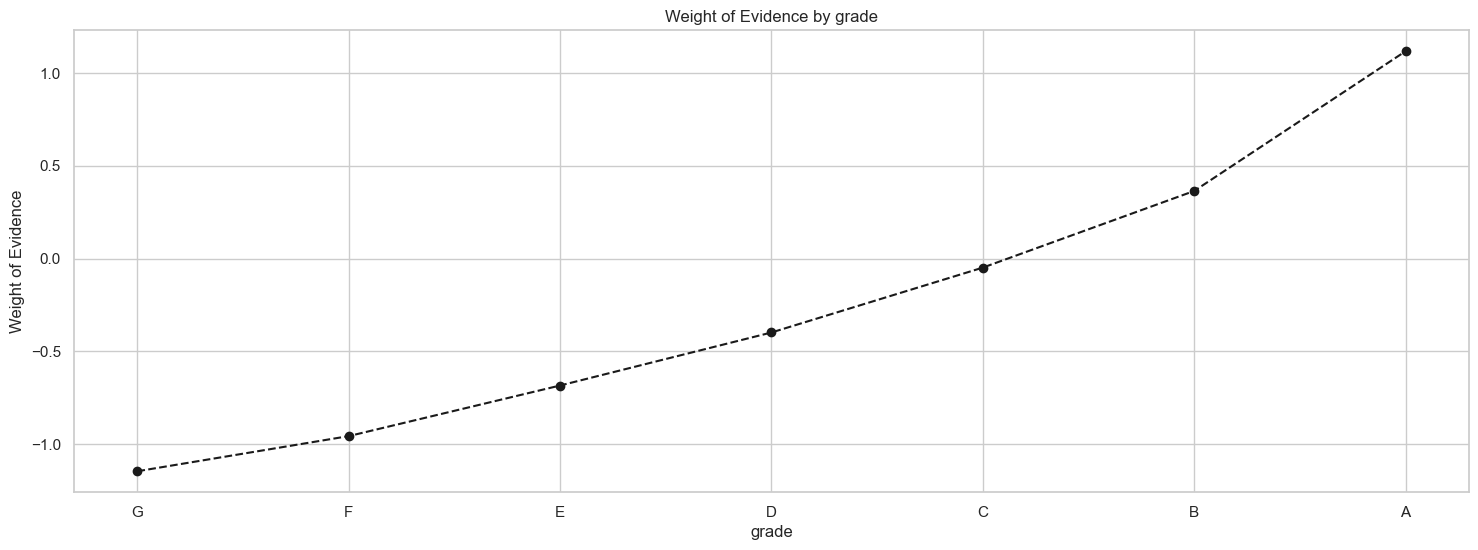

In [48]:
plot_by_woe (df_temp)

Loans with greater external rating are better on average

#### Creating dummy variables

#### Discrete Variables

In [49]:
#apply the func to calculate and visualize woe for all discrete variables
# reference category = category against which the impact of all others on the outcome will be accessed i.e  dummy var with categories with lowest woe
# 'home_ownership'
df_temp = woe_discrete(df_inputs_prepr, 'home_ownership', df_target_prepr)
# We calculate weight of evidence.
df_temp

,home_ownership,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,OTHER,159,0.792453,0.000426,126.0,33.0,0.000379,0.000809,-0.758081,NaN,NaN,0.02166
1,NONE,41,0.853659,0.000110,35.0,6.0,0.000105,0.000147,-0.334267,0.061206,0.423814,0.02166
2,RENT,150776,0.874052,0.404195,131786.0,18990.0,0.396642,0.465738,-0.160588,0.020393,0.173678,0.02166
3,OWN,33313,0.890343,0.089304,29660.0,3653.0,0.089269,0.089591,-0.003605,0.016292,0.156984,0.02166
4,MORTGAGE,188739,0.904143,0.505965,170647.0,18092.0,0.513604,0.443714,0.146272,0.013800,0.149877,0.02166


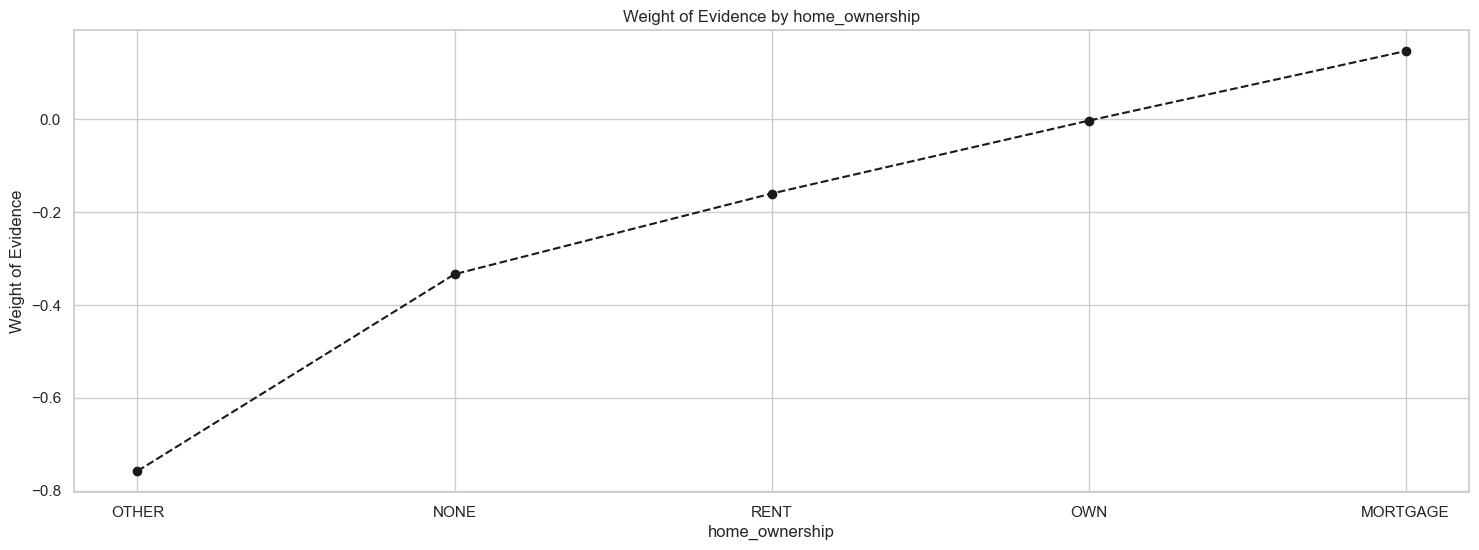

In [50]:
plot_by_woe(df_temp)

##### Category Binning or Grouping - prevents overfitting

In [51]:
# There are many categories with very few observations and many categories with very different "good" %.
# Therefore, we create a new discrete variable where we combine some of the categories.
# We combine them in one category, 'RENT_OTHER_NONE_ANY'.
# We end up with 3 categories: 'RENT_OTHER_NONE_ANY', 'OWN', 'MORTGAGE'.

# 1. Create the 'RENT_OTHER_NONE_ANY' category (Our Reference)
# "If the home_ownership column IS IN this list, mark the new column as 1"
# loan_data['home_ownership:RENT_OTHER_NONE_ANY'] = loan_data['home_ownership'].isin(['RENT', 'OTHER', 'NONE', 'ANY']).astype(int)

# # 2. Create the 'OWN' category
# loan_data['home_ownership:OWN'] = loan_data['home_ownership'].isin(['OWN']).astype(int)

# # 3. Create the 'MORTGAGE' category
# loan_data['home_ownership:MORTGAGE'] = loan_data['home_ownership'].isin(['MORTGAGE']).astype(int)
# 'RENT_OTHER_NONE_ANY' will be the reference category.

df_inputs_prepr['home_ownership:RENT_OTHER_NONE_ANY'] = sum([df_inputs_prepr['home_ownership : RENT'], 
                                                             df_inputs_prepr['home_ownership : OTHER'],
                                                             df_inputs_prepr['home_ownership : NONE'],
                                                             df_inputs_prepr['home_ownership : ANY']])

In [52]:
# 'addr_state'
df_inputs_prepr['addr_state'].unique()

array(['WI', 'TN', 'WA', 'FL', 'IL', 'TX', 'NY', 'WV', 'AL', 'NV', 'MD',
       'VA', 'CA', 'NH', 'DE', 'OH', 'NJ', 'NC', 'NM', 'AZ', 'CO', 'MA',
       'UT', 'GA', 'OR', 'SC', 'PA', 'IN', 'OK', 'MN', 'HI', 'MI', 'CT',
       'AK', 'MO', 'KY', 'AR', 'DC', 'KS', 'RI', 'LA', 'WY', 'MS', 'MT',
       'SD', 'VT', 'IA', 'NE', 'ID', 'ME'], dtype=object)

In [53]:
# We calculate weight of evidence.
df_temp = woe_discrete(df_inputs_prepr, 'addr_state', df_target_prepr)
df_temp

,addr_state,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,NE,8,0.500000,0.000021,4.0,4.0,0.000012,0.000098,-2.097855,NaN,NaN,inf
1,IA,7,0.857143,0.000019,6.0,1.0,0.000018,0.000025,-0.306096,0.357143,1.791759,inf
2,NV,5238,0.863498,0.014042,4523.0,715.0,0.013613,0.017536,-0.253207,0.006355,0.052889,inf
3,FL,25259,0.873273,0.067713,22058.0,3201.0,0.066389,0.078506,-0.167643,0.009775,0.085564,inf
4,HI,2012,0.876740,0.005394,1764.0,248.0,0.005309,0.006082,-0.135945,0.003467,0.031698,inf
5,AL,4698,0.877607,0.012594,4123.0,575.0,0.012409,0.014102,-0.127889,0.000868,0.008056,inf
6,MD,8811,0.882874,0.023620,7779.0,1032.0,0.023413,0.025310,-0.077926,0.005266,0.049963,inf
7,OK,3301,0.883369,0.008849,2916.0,385.0,0.008776,0.009442,-0.073130,0.000495,0.004796,inf
8,NY,32111,0.884339,0.086082,28397.0,3714.0,0.085468,0.091087,-0.063681,0.000970,0.009449,inf
9,NM,2077,0.884449,0.005568,1837.0,240.0,0.005529,0.005886,-0.062605,0.000110,0.001076,inf


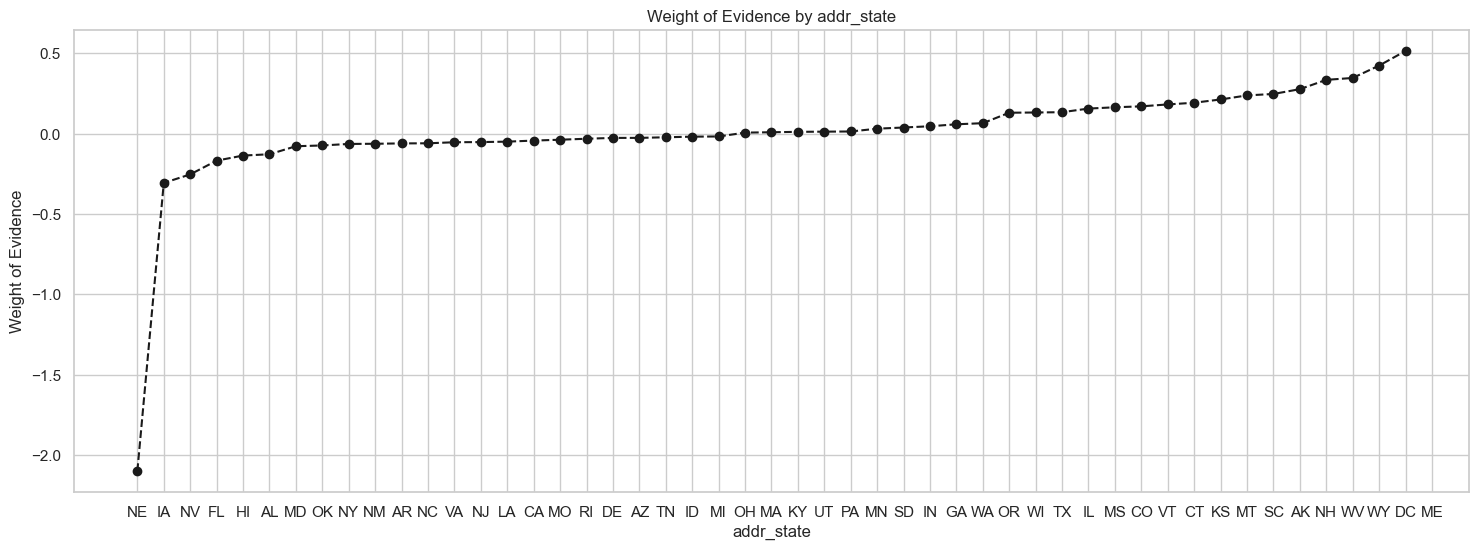

In [54]:
plot_by_woe(df_temp)

In [55]:
#create a dummy var for ND 
if ['addr_state : ND'] in df_inputs_prepr.columns.values:
    pass
else:
    df_inputs_prepr['addr_state : ND'] = 0

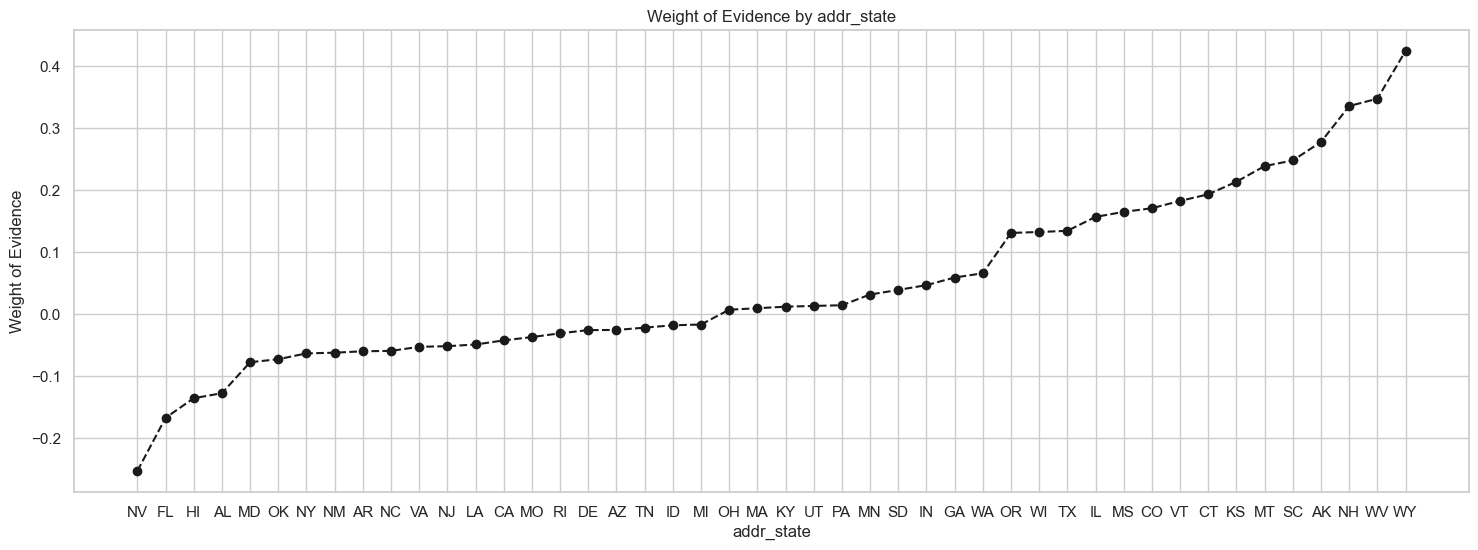

In [56]:
# the first two and last two have few observations
plot_by_woe(df_temp.iloc[2: -2, : ])


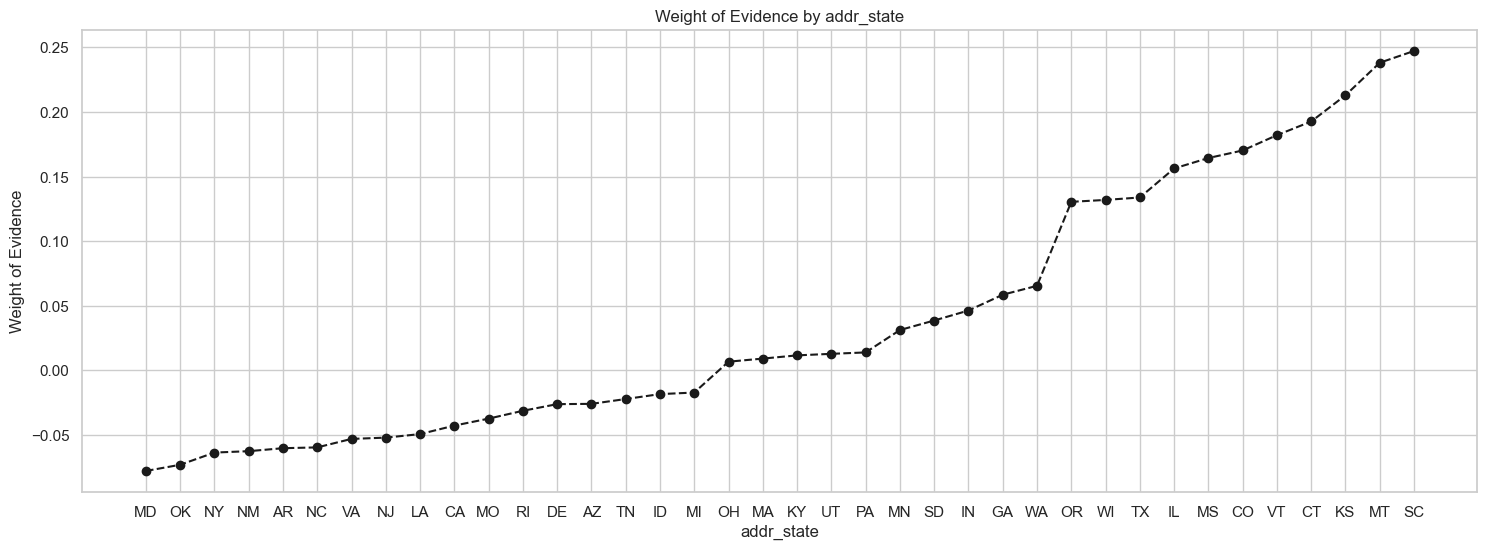

In [57]:
plot_by_woe(df_temp.iloc[6:-6,:])

In [58]:
# keep first state in diff category, same to the next 3 states, the first two states left out above
# place the state we have no info about in the worst/highest risk
#consider no of observations, similarity in woe
# leave out the reference category which is the category with the lowest woe

# Grouping states by risk (WoE) and number of observations
# prevents the model from making huge assumptions based on just a handful of borrowers.

df_inputs_prepr['addr_state : ND_NE_IA_NV_FL_HI_AL'] = sum([df_inputs_prepr['addr_state : ND'], df_inputs_prepr['addr_state : NE'],
                                                              df_inputs_prepr['addr_state : IA'], df_inputs_prepr['addr_state : NV'],
                                                              df_inputs_prepr['addr_state : FL'], df_inputs_prepr['addr_state : HI'],
                                                              df_inputs_prepr['addr_state : AL']])

df_inputs_prepr['addr_state : NM_VA'] = sum([df_inputs_prepr['addr_state : NM'], df_inputs_prepr['addr_state : VA']])

df_inputs_prepr['addr_state : OK_TN_MO_LA_MD_NC'] = sum([df_inputs_prepr['addr_state : OK'], df_inputs_prepr['addr_state : TN'],
                                                              df_inputs_prepr['addr_state : MO'], df_inputs_prepr['addr_state : LA'],
                                                              df_inputs_prepr['addr_state : MD'], df_inputs_prepr['addr_state : NC']])

df_inputs_prepr['addr_state : UT_KY_AZ_NJ'] = sum([df_inputs_prepr['addr_state : UT'], df_inputs_prepr['addr_state : KY'],
                                                              df_inputs_prepr['addr_state : AZ'], df_inputs_prepr['addr_state : NJ']])

df_inputs_prepr['addr_state : AR_MI_PA_OH_MN'] = sum([df_inputs_prepr['addr_state : AR'], df_inputs_prepr['addr_state : MI'],
                                                              df_inputs_prepr['addr_state : PA'], df_inputs_prepr['addr_state : OH'],
                                                              df_inputs_prepr['addr_state : MN']])

df_inputs_prepr['addr_state : RI_MA_DE_SD_IN'] = sum([df_inputs_prepr['addr_state : RI'], df_inputs_prepr['addr_state : MA'],
                                                              df_inputs_prepr['addr_state : DE'], df_inputs_prepr['addr_state : SD'],
                                                              df_inputs_prepr['addr_state : IN']])

df_inputs_prepr['addr_state : GA_WA_OR'] = sum([df_inputs_prepr['addr_state : GA'], df_inputs_prepr['addr_state : WA'],
                                                              df_inputs_prepr['addr_state : OR']])

df_inputs_prepr['addr_state : WI_MT'] = sum([df_inputs_prepr['addr_state : WI'], df_inputs_prepr['addr_state : MT']])

df_inputs_prepr['addr_state : IL_CT'] = sum([df_inputs_prepr['addr_state : IL'], df_inputs_prepr['addr_state : CT']])

df_inputs_prepr['addr_state : KS_SC_CO_VT_AK_MS'] = sum([df_inputs_prepr['addr_state : KS'], df_inputs_prepr['addr_state : SC'],
                                                              df_inputs_prepr['addr_state : CO'], df_inputs_prepr['addr_state : VT'],
                                                              df_inputs_prepr['addr_state : AK'], df_inputs_prepr['addr_state : MS']])

df_inputs_prepr['addr_state : WV_NH_WY_DC_ME_ID'] = sum([df_inputs_prepr['addr_state : WV'], df_inputs_prepr['addr_state : NH'],
                                                              df_inputs_prepr['addr_state : WY'], df_inputs_prepr['addr_state : DC'],
                                                              df_inputs_prepr['addr_state : ME'], df_inputs_prepr['addr_state : ID']])

#IA_NV_HI_ID_AL_FL' will be the reference category.

In [59]:
# calculate weight of evidence for'verification_status'
df_temp = woe_discrete(df_inputs_prepr, 'verification_status', df_target_prepr)
df_temp

,verification_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,Verified,134571,0.872045,0.360753,117352.0,17219.0,0.353200,0.422303,-0.178691,NaN,NaN,0.022522
1,Source Verified,119969,0.895723,0.321609,107459.0,12510.0,0.323424,0.306813,0.052726,0.023678,0.231417,0.022522
2,Not Verified,118488,0.906784,0.317638,107443.0,11045.0,0.323376,0.270883,0.177128,0.011061,0.124402,0.022522


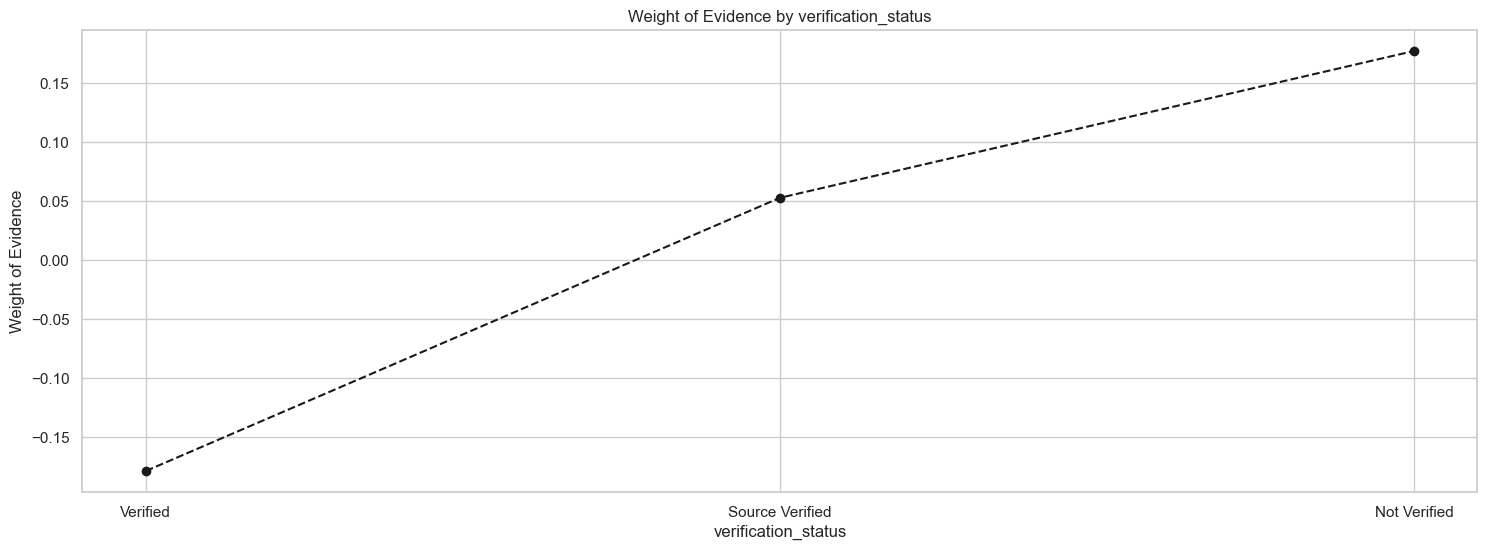

In [60]:
plot_by_woe(df_temp)

In [61]:
# calculate weight of evidence for 'purpose'
df_temp = woe_discrete(df_inputs_prepr, 'purpose', df_target_prepr)
df_temp

,purpose,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,small_business,5605,0.787333,0.015026,4413.0,1192.0,0.013282,0.029234,-0.788933,NaN,NaN,0.036668
1,educational,351,0.792023,0.000941,278.0,73.0,0.000837,0.001790,-0.760693,0.004690,0.028240,0.036668
2,renewable_energy,295,0.837288,0.000791,247.0,48.0,0.000743,0.001177,-0.459668,0.045265,0.301026,0.036668
3,moving,2397,0.848561,0.006426,2034.0,363.0,0.006122,0.008903,-0.374498,0.011273,0.085169,0.036668
4,house,1824,0.861294,0.004890,1571.0,253.0,0.004728,0.006205,-0.271777,0.012733,0.102721,0.036668
5,other,19006,0.861675,0.050951,16377.0,2629.0,0.049291,0.064477,-0.268581,0.000381,0.003196,0.036668
6,medical,3750,0.863467,0.010053,3238.0,512.0,0.009746,0.012557,-0.253469,0.001791,0.015112,0.036668
7,vacation,2003,0.875686,0.005370,1754.0,249.0,0.005279,0.006107,-0.145654,0.012220,0.107815,0.036668
8,wedding,1900,0.881053,0.005093,1674.0,226.0,0.005038,0.005543,-0.095419,0.005366,0.050235,0.036668
9,debt_consolidation,219196,0.886704,0.587613,194362.0,24834.0,0.584980,0.609065,-0.040346,0.005652,0.055072,0.036668


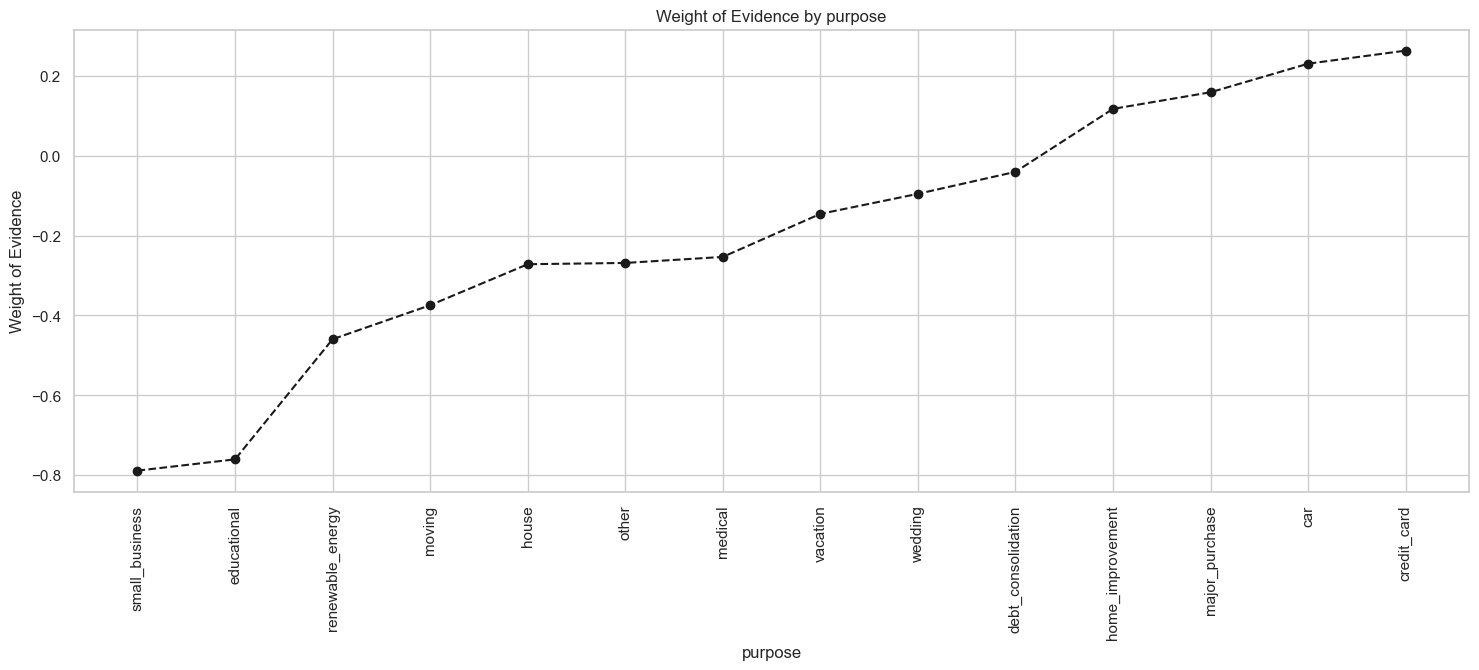

In [62]:
plot_by_woe(df_temp,90)

In [63]:
# We combine 'educational', 'small_business', 'wedding', 'renewable_energy', 'moving', 'house' in one category: 'educ__sm_b__wedd__ren_en__mov__house'.
# We combine 'other', 'medical', 'vacation' in one category: 'oth__med__vacation'.
# We combine 'major_purchase', 'car', 'home_improvement' in one category: 'major_purch__car__home_impr'.
# We leave 'debt_consolidtion' in a separate category.
# We leave 'credit_card' in a separate category.
# 'educ__sm_b__wedd__ren_en__mov__house' will be the reference category.
# Grouping loan purposes by risk (WoE)
# We use 'purpose : category' to match your naming convention

df_inputs_prepr['purpose : educ__sm_b__wedd__ren_en__mov__house'] = sum([
    df_inputs_prepr['purpose : educational'], 
    df_inputs_prepr['purpose : small_business'],
    df_inputs_prepr['purpose : wedding'], 
    df_inputs_prepr['purpose : renewable_energy'],
    df_inputs_prepr['purpose : moving'], 
    df_inputs_prepr['purpose : house']
])

df_inputs_prepr['purpose : oth__med__vacation'] = sum([
    df_inputs_prepr['purpose : other'], 
    df_inputs_prepr['purpose : medical'],
    df_inputs_prepr['purpose : vacation']
])

df_inputs_prepr['purpose : major_purch__car__home_impr'] = sum([
    df_inputs_prepr['purpose : major_purchase'], 
    df_inputs_prepr['purpose : car'],
    df_inputs_prepr['purpose : home_improvement']
])

In [64]:
# woe for 'initial_list_status'
df_temp = woe_discrete(df_inputs_prepr, 'initial_list_status', df_target_prepr)
df_temp

,initial_list_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,f,242325,0.879550,0.649616,213137.0,29188.0,0.641488,0.715848,-0.109678,NaN,NaN,0.025441
1,w,130703,0.911356,0.350384,119117.0,11586.0,0.358512,0.284152,0.232454,0.031806,0.342131,0.025441


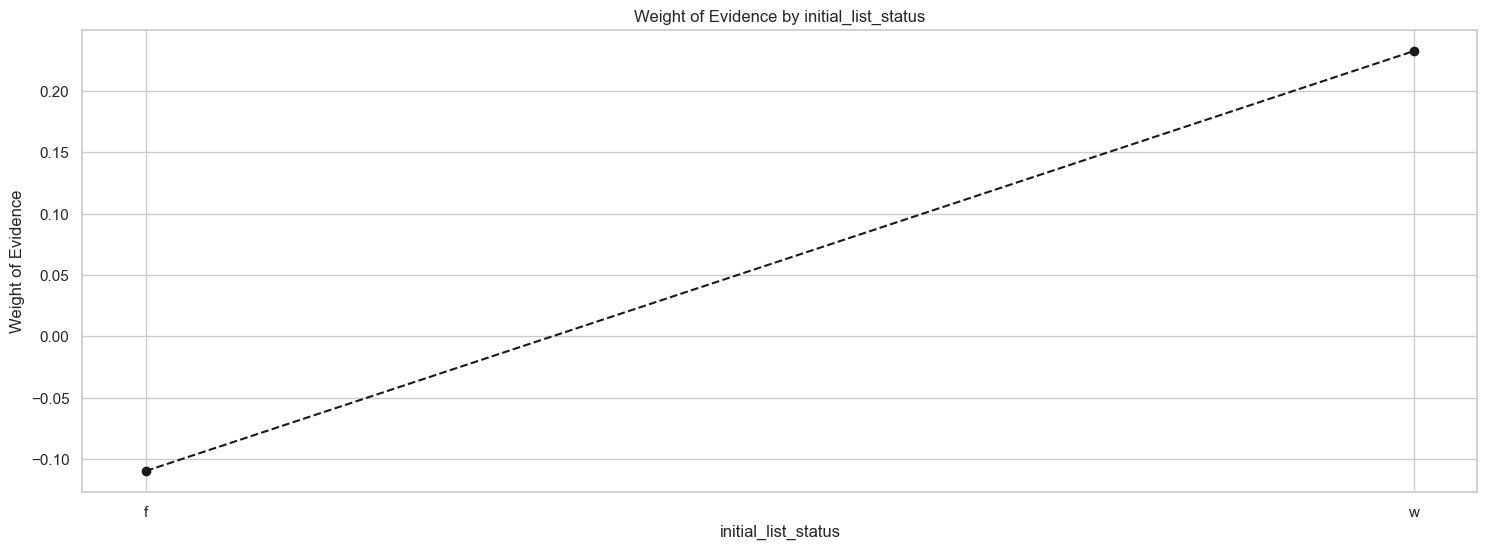

In [65]:
plot_by_woe(df_temp)

#### Creating dummy variables

#### Continuous variables - Automating Calculations and Visualizing Results¶

In [66]:
# WoE function for ordered discrete and continuous variables
def woe_ordered_continuous(df, discrete_variabe_name, good_bad_variable_df):
    df = pd.concat([df[discrete_variabe_name], good_bad_variable_df], axis = 1)
    df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
                    df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], 'n_obs', 'prop_good']
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_good'] = df['prop_good'] * df['n_obs']
    df['n_bad'] = (1 - df['prop_good']) * df['n_obs']
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad'] / df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    #df = df.sort_values(['WoE'])
    #df = df.reset_index(drop = True)
    df['diff_prop_good'] = df['prop_good'].diff().abs()
    df['diff_WoE'] = df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    return df
# Here we define a function similar to the one above, ...
# ... with one slight difference: we order the results by the values of a different column.
# The function takes 3 arguments: a dataframe, a string, and a dataframe. The function returns a dataframe as a result.

In [67]:
df_inputs_prepr['term_int'].unique()

array([36, 60])

In [68]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'term_int', df_target_prepr)
# We calculate weight of evidence.
df_temp

,term_int,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,36,270199,0.903238,0.72434,244054.0,26145.0,0.73454,0.641217,0.135876,NaN,NaN,0.040794
1,60,102829,0.857735,0.27566,88200.0,14629.0,0.26546,0.358783,-0.301254,0.045503,0.43713,0.040794


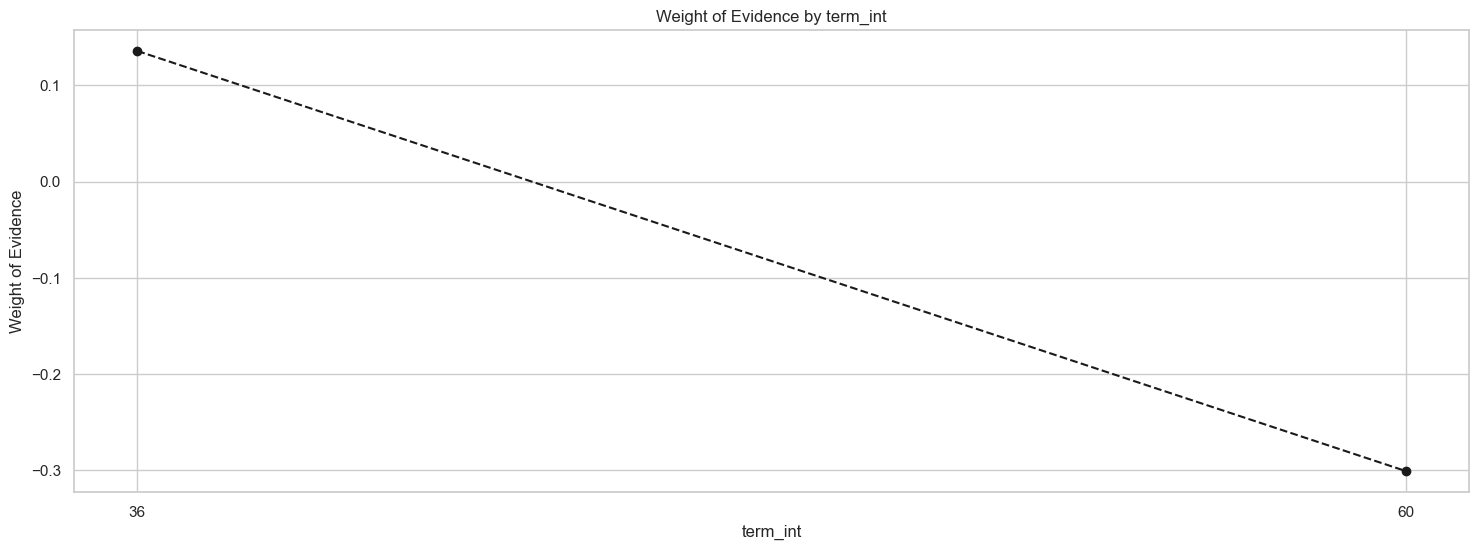

In [69]:
plot_by_woe(df_temp)
# We plot the weight of evidence values.

In [70]:
# '60' will be the reference category.
df_inputs_prepr['term:36'] = np.where((df_inputs_prepr['term_int'] == 36), 1, 0) # np.where works similar to excel if
df_inputs_prepr['term:60'] = np.where((df_inputs_prepr['term_int'] == 60), 1, 0)

In [71]:
# emp_length_int
df_inputs_prepr['emp_length_int'].unique()
# Has only 11 levels: from 0 to 10. Hence, we turn it into a factor with 11 levels.

array([ 7., 10.,  3.,  4.,  2.,  0.,  1.,  6.,  5.,  8.,  9.])

In [72]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'emp_length_int', df_target_prepr)
# We calculate weight of evidence.
df_temp

,emp_length_int,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,45764,0.876497,0.122682,40112.0,5652.0,0.120727,0.138618,-0.138189,NaN,NaN,0.006408
1,1.0,23582,0.888262,0.063218,20947.0,2635.0,0.063045,0.064625,-0.024743,0.011765,0.113446,0.006408
2,2.0,33123,0.889895,0.088795,29476.0,3647.0,0.088715,0.089444,-0.008184,0.001633,0.016559,0.006408
3,3.0,29301,0.890925,0.078549,26105.0,3196.0,0.078569,0.078383,0.002372,0.001030,0.010555,0.006408
4,4.0,22482,0.891602,0.060269,20045.0,2437.0,0.060330,0.059768,0.009357,0.000677,0.006985,0.006408
5,5.0,24654,0.885374,0.066092,21828.0,2826.0,0.065697,0.069309,-0.053524,0.006229,0.062881,0.006408
6,6.0,21057,0.883079,0.056449,18595.0,2462.0,0.055966,0.060382,-0.075936,0.002294,0.022413,0.006408
7,7.0,20834,0.887204,0.055851,18484.0,2350.0,0.055632,0.057635,-0.035365,0.004124,0.040571,0.006408
8,8.0,17859,0.889300,0.047876,15882.0,1977.0,0.047801,0.048487,-0.014249,0.002096,0.021116,0.006408
9,9.0,14372,0.887142,0.038528,12750.0,1622.0,0.038374,0.039780,-0.035984,0.002158,0.021735,0.006408


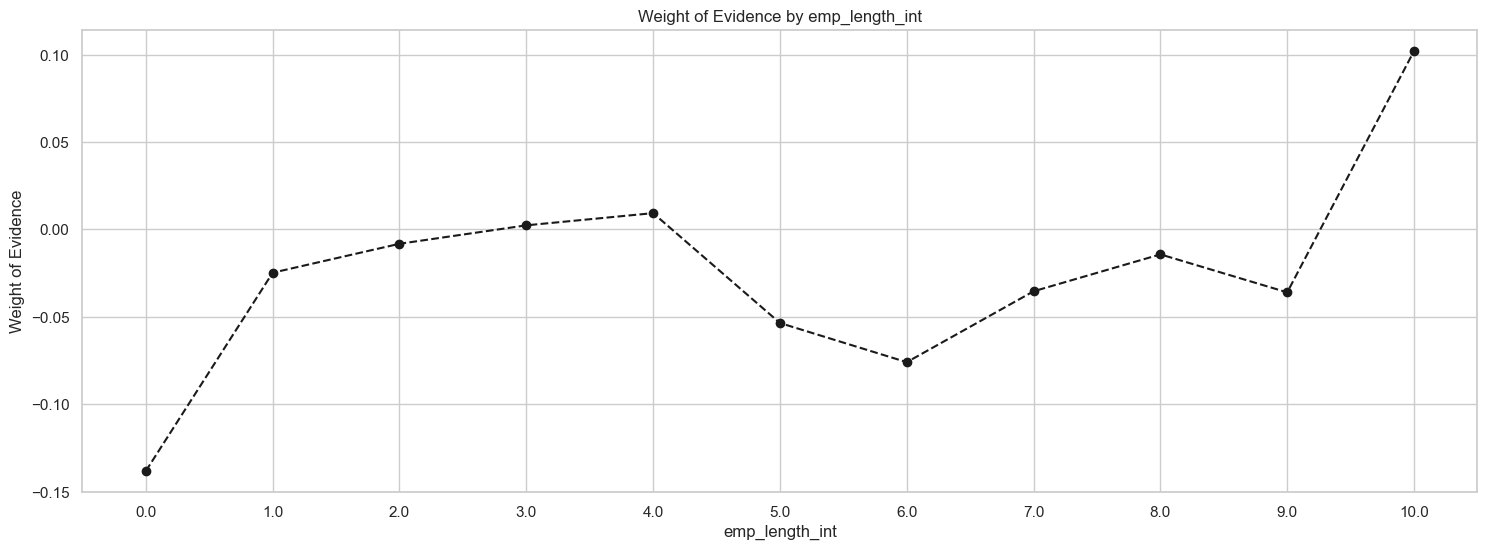

In [73]:
plot_by_woe(df_temp)
# We plot the weight of evidence values.

##### Course classing

In [74]:
# We create the following categories: '0', '1', '2 - 4', '5 - 6', '7 - 9', '10'
# '0' will be the reference category
df_inputs_prepr['emp_length:0'] = np.where(df_inputs_prepr['emp_length_int'].isin([0]), 1, 0)
df_inputs_prepr['emp_length:1'] = np.where(df_inputs_prepr['emp_length_int'].isin([1]), 1, 0)
df_inputs_prepr['emp_length:2-4'] = np.where(df_inputs_prepr['emp_length_int'].isin(range(2, 5)), 1, 0) #range includes lower bound but excludes upper bound
df_inputs_prepr['emp_length:5-6'] = np.where(df_inputs_prepr['emp_length_int'].isin(range(5, 7)), 1, 0)
df_inputs_prepr['emp_length:7-9'] = np.where(df_inputs_prepr['emp_length_int'].isin(range(7, 10)), 1, 0)
df_inputs_prepr['emp_length:10'] = np.where(df_inputs_prepr['emp_length_int'].isin([10]), 1, 0)

In [75]:
df_inputs_prepr['mths_since_issue_d'].unique()

<IntegerArray>
[ 47,  43,  52,  55,  37,  40,  41,  49,  44,  72,  38,  61,  76,  51,  58,
  54,  59, 105,  74,  56,  75,  53,  68,  62,  39,  45,  64,  48,  73,  42,
  81,  57,  89,  70,  71,  36,  50,  46, 118,  79,  63,  90,  88,  67,  60,
  78,  82,  84,  96,  69,  83,  97, 125, 107, 103,  66,  65,  86,  77,  92,
  80,  98,  94, 119,  91, 117,  87, 102, 116, 109,  85, 110,  95,  99, 115,
 101, 112, 120, 104, 113, 100,  93, 106, 121, 122, 108, 124, 114, 123, 111,
 126]
Length: 91, dtype: Int64

Fine classing - roughly grouping the values into categories

coarse classing - determining final categories 

In [76]:
df_inputs_prepr['mths_since_issue_d_factor'] = pd.cut(df_inputs_prepr['mths_since_issue_d'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
#factor says that the var is categorical

In [77]:
df_inputs_prepr['mths_since_issue_d_factor']

456615      (46.8, 48.6]
451541      (46.8, 48.6]
394474      (41.4, 43.2]
110294      (50.4, 52.2]
139343      (54.0, 55.8]
               ...      
163633      (57.6, 59.4]
399306      (41.4, 43.2]
57787       (48.6, 50.4]
81641       (48.6, 50.4]
38736     (113.4, 115.2]
Name: mths_since_issue_d_factor, Length: 373028, dtype: category
Categories (50, interval[float64, right]): [(35.91, 37.8] < (37.8, 39.6] < (39.6, 41.4] < (41.4, 43.2] ... (118.8, 120.6] < (120.6, 122.4] < (122.4, 124.2] < (124.2, 126.0]]

In [78]:
# mths_since_issue_d
df_temp = woe_ordered_continuous(df_inputs_prepr, 'mths_since_issue_d_factor', df_target_prepr)
# We calculate weight of evidence.
df_temp

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,mths_since_issue_d_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(35.91, 37.8]",28350,0.942187,0.076000,26711.0,1639.0,0.080393,0.040197,0.693134,NaN,NaN,0.111991
1,"(37.8, 39.6]",39515,0.928660,0.105930,36696.0,2819.0,0.110446,0.069137,0.468430,0.013527,0.224704,0.111991
2,"(39.6, 41.4]",38298,0.917594,0.102668,35142.0,3156.0,0.105768,0.077402,0.312236,0.011066,0.156194,0.111991
3,"(41.4, 43.2]",29136,0.907297,0.078107,26435.0,2701.0,0.079563,0.066243,0.183212,0.010297,0.129025,0.111991
4,"(43.2, 45.0]",28449,0.902211,0.076265,25667.0,2782.0,0.077251,0.068230,0.124181,0.005086,0.059031,0.111991
5,"(45.0, 46.8]",12231,0.898046,0.032788,10984.0,1247.0,0.033059,0.030583,0.077844,0.004165,0.046337,0.111991
6,"(46.8, 48.6]",24497,0.896232,0.065671,21955.0,2542.0,0.066079,0.062344,0.058189,0.001814,0.019655,0.111991
7,"(48.6, 50.4]",23122,0.889240,0.061985,20561.0,2561.0,0.061883,0.062810,-0.014857,0.006993,0.073045,0.111991
8,"(50.4, 52.2]",20565,0.880866,0.055130,18115.0,2450.0,0.054522,0.060087,-0.097203,0.008374,0.082346,0.111991
9,"(52.2, 54.0]",18305,0.868342,0.049071,15895.0,2410.0,0.047840,0.059106,-0.211477,0.012524,0.114274,0.111991


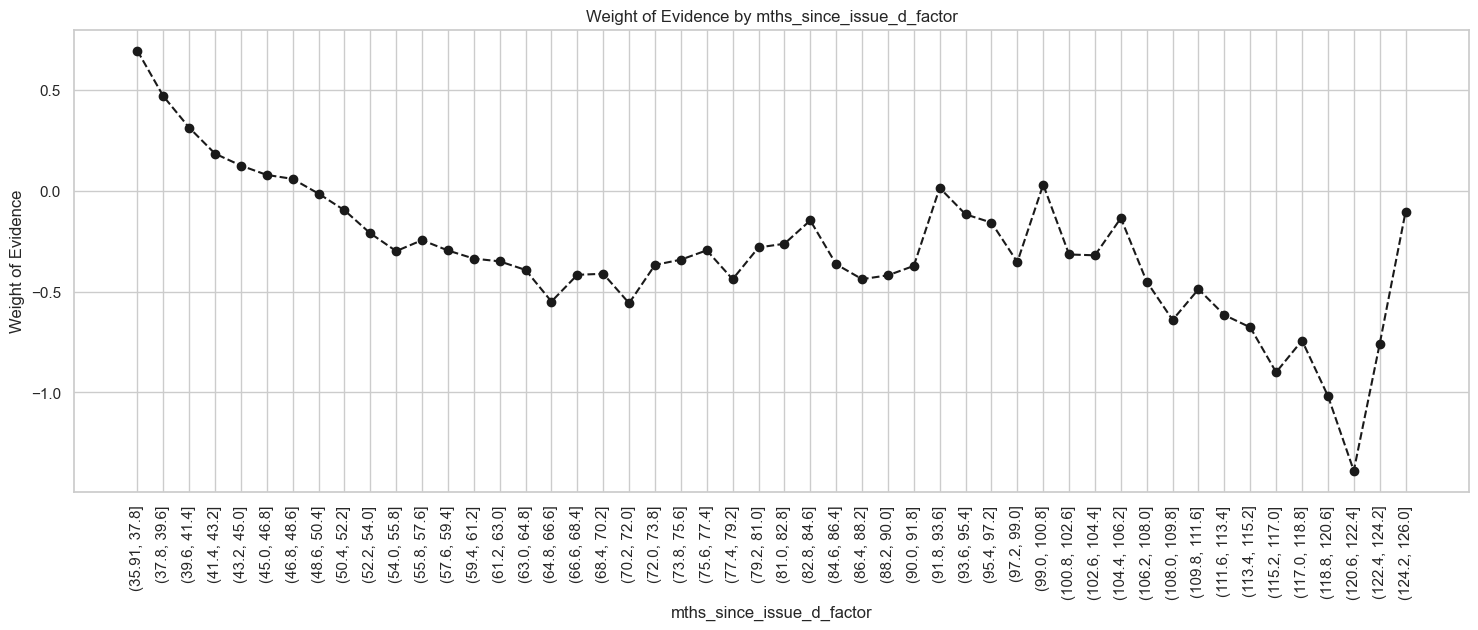

In [79]:
plot_by_woe(df_temp, 90)
# We plot the weight of evidence values.
# We have to rotate the labels because we cannot read them otherwise.

In [80]:
# We create the following categories:
# < 38, 38 - 39, 40 - 41, 42 - 48, 49 - 52, 53 - 64, 65 - 84, > 84.
df_inputs_prepr['mths_since_issue_d:<38'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(38)), 1, 0) #range is used with integer numbers
df_inputs_prepr['mths_since_issue_d:38-39'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(38, 40)), 1, 0)
df_inputs_prepr['mths_since_issue_d:40-41'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(40, 42)), 1, 0)
df_inputs_prepr['mths_since_issue_d:42-48'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(42, 49)), 1, 0)
df_inputs_prepr['mths_since_issue_d:49-52'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(49, 53)), 1, 0)
df_inputs_prepr['mths_since_issue_d:53-64'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(53, 65)), 1, 0)
df_inputs_prepr['mths_since_issue_d:65-84'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(65, 85)), 1, 0)
df_inputs_prepr['mths_since_issue_d:>84'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(85, int(df_inputs_prepr['mths_since_issue_d'].max()))), 1, 0)

In [81]:
# int_rate
df_inputs_prepr['int_rate_factor'] = pd.cut(df_inputs_prepr['int_rate'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.

In [82]:
df_temp = woe_ordered_continuous(df_inputs_prepr, 'int_rate_factor', df_target_prepr)
# We calculate weight of evidence.
df_temp

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,int_rate_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(5.399, 5.833]",776,0.962629,0.002080,747.0,29.0,0.002248,0.000711,1.150914,NaN,NaN,0.346603
1,"(5.833, 6.246]",8408,0.979305,0.022540,8234.0,174.0,0.024782,0.004267,1.759117,0.016677,0.608203,0.346603
2,"(6.246, 6.658]",7842,0.971181,0.021023,7616.0,226.0,0.022922,0.005543,1.419616,0.008125,0.339500,0.346603
3,"(6.658, 7.071]",1777,0.969612,0.004764,1723.0,54.0,0.005186,0.001324,1.364983,0.001569,0.054633,0.346603
4,"(7.071, 7.484]",3186,0.976146,0.008541,3110.0,76.0,0.009360,0.001864,1.613790,0.006534,0.248806,0.346603
5,"(7.484, 7.897]",12590,0.963781,0.033751,12134.0,456.0,0.036520,0.011184,1.183419,0.012365,0.430371,0.346603
6,"(7.897, 8.31]",9680,0.949483,0.025950,9191.0,489.0,0.027663,0.011993,0.835762,0.014297,0.347656,0.346603
7,"(8.31, 8.722]",6666,0.965047,0.017870,6433.0,233.0,0.019362,0.005714,1.220303,0.015563,0.384540,0.346603
8,"(8.722, 9.135]",9578,0.938923,0.025676,8993.0,585.0,0.027067,0.014347,0.634735,0.026124,0.585568,0.346603
9,"(9.135, 9.548]",6563,0.965565,0.017594,6337.0,226.0,0.019073,0.005543,1.235771,0.026642,0.601036,0.346603


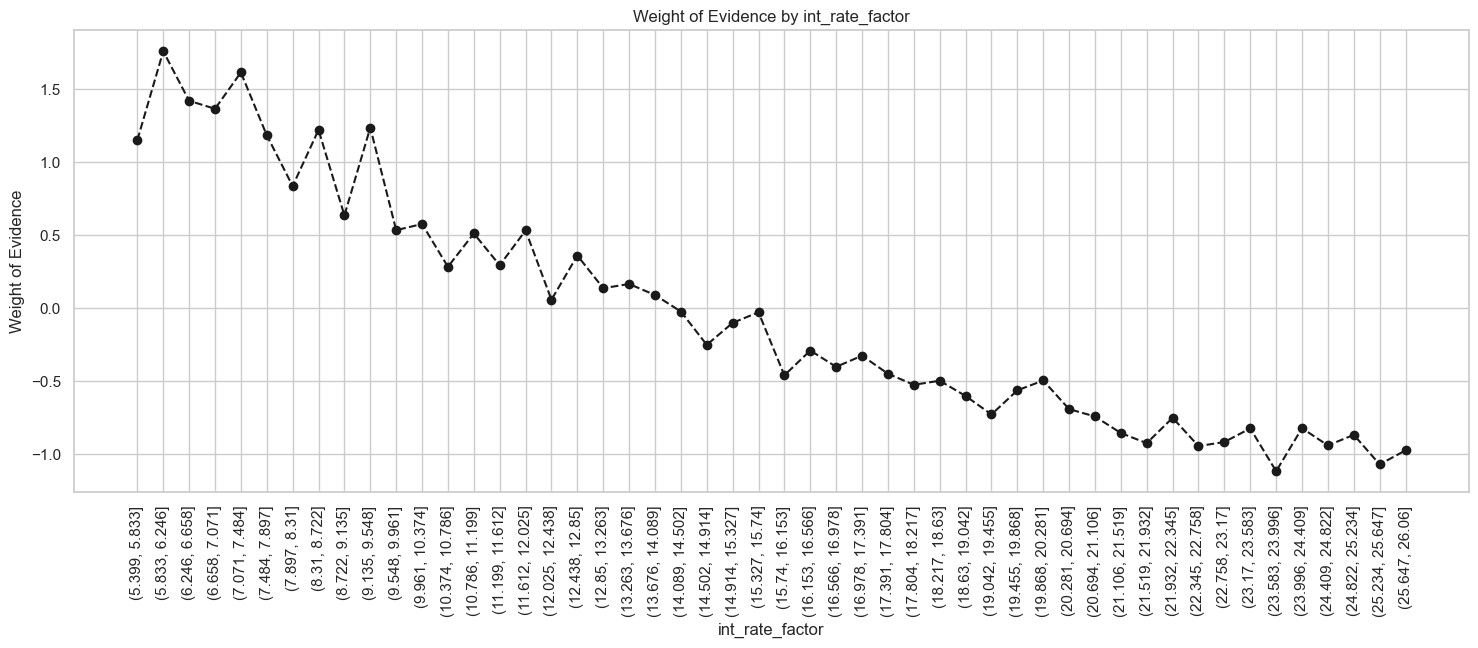

In [83]:
plot_by_woe(df_temp, 90)
# We plot the weight of evidence values.

In [84]:
df_inputs_prepr['int_rate:<9.548'] = np.where((df_inputs_prepr['int_rate'] <= 9.548), 1, 0)
df_inputs_prepr['int_rate:9.548-12.025'] = np.where((df_inputs_prepr['int_rate'] > 9.548) & (df_inputs_prepr['int_rate'] <= 12.025), 1, 0)
df_inputs_prepr['int_rate:12.025-15.74'] = np.where((df_inputs_prepr['int_rate'] > 12.025) & (df_inputs_prepr['int_rate'] <= 15.74), 1, 0)
df_inputs_prepr['int_rate:15.74-20.281'] = np.where((df_inputs_prepr['int_rate'] > 15.74) & (df_inputs_prepr['int_rate'] <= 20.281), 1, 0)
df_inputs_prepr['int_rate:>20.281'] = np.where((df_inputs_prepr['int_rate'] > 20.281), 1, 0)

In [85]:
# funded_amnt
df_inputs_prepr['funded_amnt_factor'] = pd.cut(df_inputs_prepr['funded_amnt'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'funded_amnt_factor', df_target_prepr)
# We calculate weight of evidence.
df_temp

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,funded_amnt_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(465.5, 1190.0]",1241,0.900081,0.003327,1117.0,124.0,0.003362,0.003041,0.100265,NaN,NaN,0.014394
1,"(1190.0, 1880.0]",3086,0.904407,0.008273,2791.0,295.0,0.008400,0.007235,0.149325,0.004326,0.049060,0.014394
2,"(1880.0, 2570.0]",6047,0.895981,0.016211,5418.0,629.0,0.016307,0.015426,0.055496,0.008426,0.093829,0.014394
3,"(2570.0, 3260.0]",7255,0.891247,0.019449,6466.0,789.0,0.019461,0.019351,0.005692,0.004734,0.049804,0.014394
4,"(3260.0, 3950.0]",4756,0.889613,0.012750,4231.0,525.0,0.012734,0.012876,-0.011060,0.001634,0.016751,0.014394
5,"(3950.0, 4640.0]",9054,0.890104,0.024272,8059.0,995.0,0.024256,0.024403,-0.006053,0.000491,0.005007,0.014394
6,"(4640.0, 5330.0]",15927,0.894770,0.042697,14251.0,1676.0,0.042892,0.041105,0.042562,0.004666,0.048615,0.014394
7,"(5330.0, 6020.0]",17206,0.906486,0.046125,15597.0,1609.0,0.046943,0.039461,0.173611,0.011716,0.131049,0.014394
8,"(6020.0, 6710.0]",6910,0.886541,0.018524,6126.0,784.0,0.018438,0.019228,-0.041967,0.019945,0.215577,0.014394
9,"(6710.0, 7400.0]",11745,0.897829,0.031486,10545.0,1200.0,0.031738,0.029431,0.075475,0.011288,0.117442,0.014394


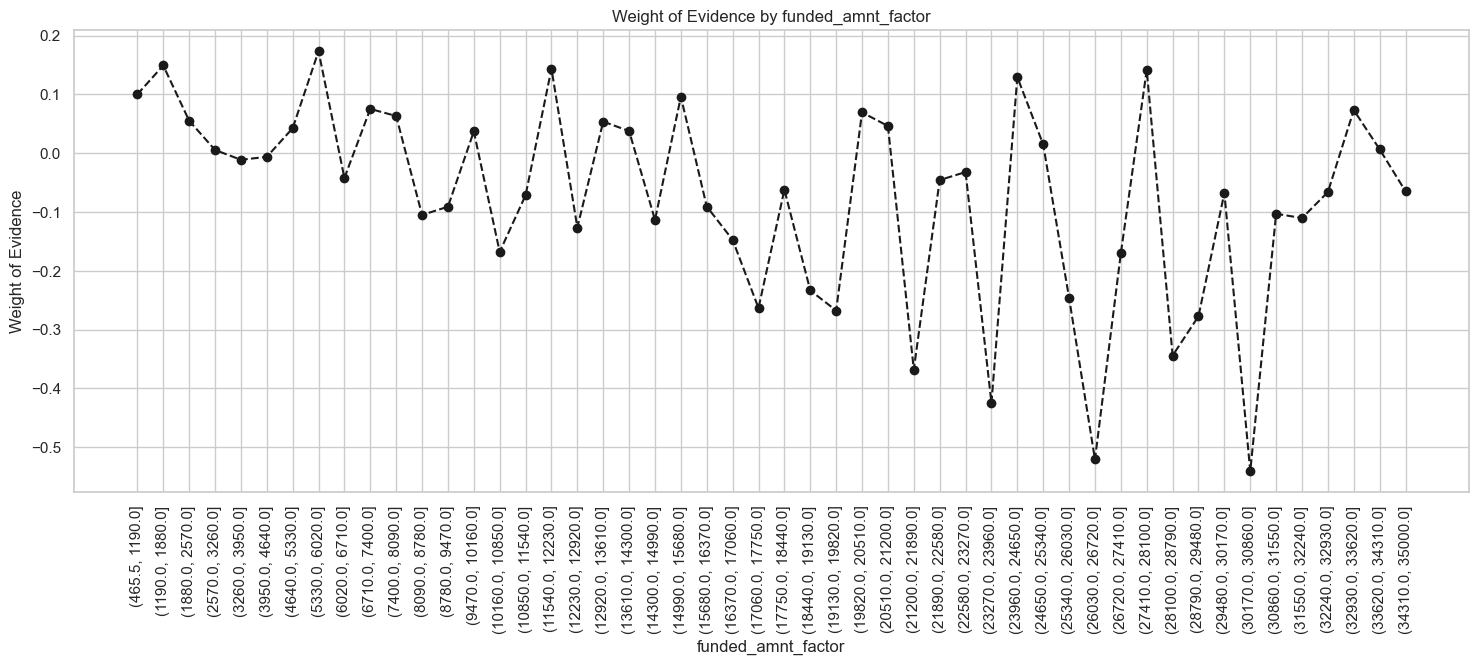

In [86]:
plot_by_woe(df_temp, 90)
# We plot the weight of evidence values. It varies greatly so there's no asscoaition hence we don't use this var in the pd model

In [87]:
# mths_since_earliest_cr_line
df_inputs_prepr['mths_since_earliest_cr_line_factor'] = pd.cut(df_inputs_prepr['mths_since_earliest_cr_line'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'mths_since_earliest_cr_line_factor', df_target_prepr)
# We calculate weight of evidence.
df_temp

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,mths_since_earliest_cr_line_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.887, 17.74]",25,0.880000,0.000067,22.0,3.0,0.000066,0.000074,-0.105425,NaN,NaN,inf
1,"(17.74, 35.48]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf
2,"(35.48, 53.22]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf
3,"(53.22, 70.96]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf
4,"(70.96, 88.7]",1792,0.904576,0.004804,1621.0,171.0,0.004879,0.004194,0.151280,NaN,NaN,inf
5,"(88.7, 106.44]",3920,0.858929,0.010509,3367.0,553.0,0.010134,0.013563,-0.291436,0.045647,0.442716,inf
6,"(106.44, 124.18]",10070,0.870308,0.026995,8764.0,1306.0,0.026377,0.032030,-0.194172,0.011379,0.097264,inf
7,"(124.18, 141.92]",16721,0.864183,0.044825,14450.0,2271.0,0.043491,0.055697,-0.247381,0.006125,0.053209,inf
8,"(141.92, 159.66]",21771,0.878508,0.058363,19126.0,2645.0,0.057564,0.064870,-0.119478,0.014325,0.127903,inf
9,"(159.66, 177.4]",27817,0.881943,0.074571,24533.0,3284.0,0.073838,0.080542,-0.086898,0.003435,0.032579,inf


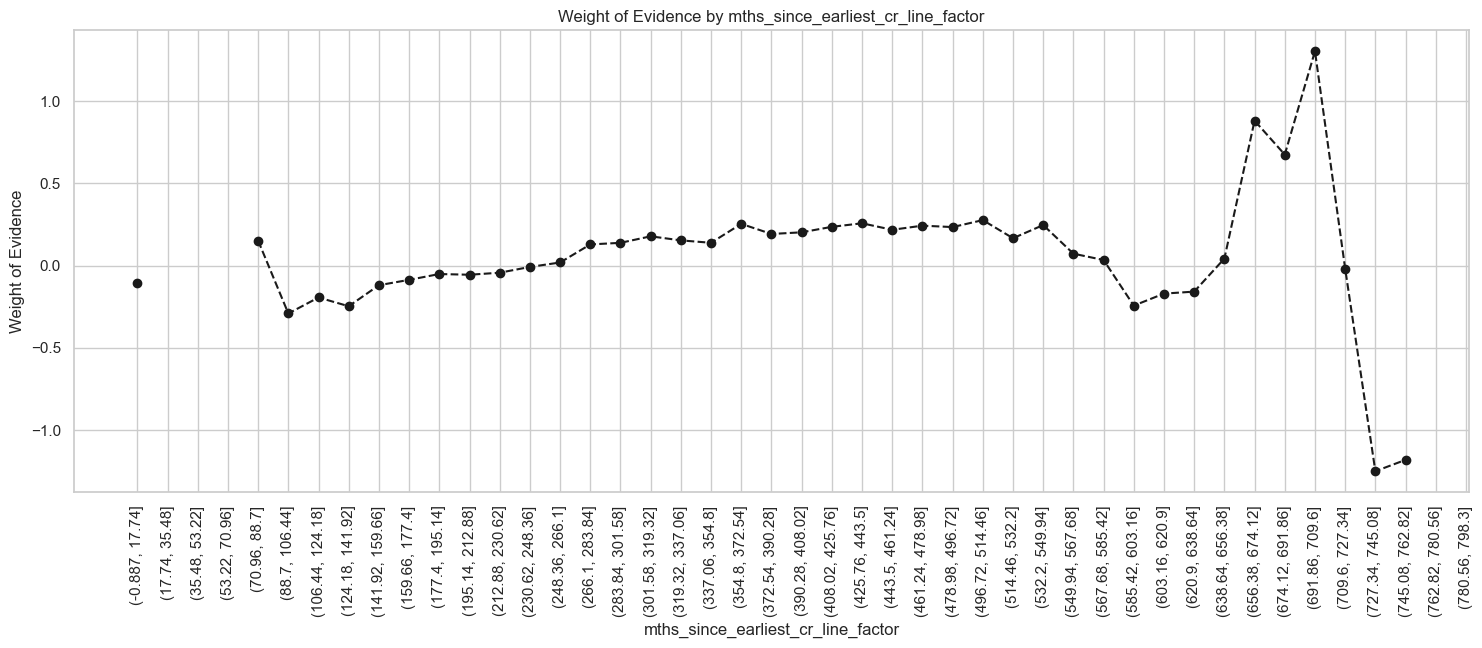

In [88]:
plot_by_woe(df_temp, 90)
# We plot the weight of evidence values.

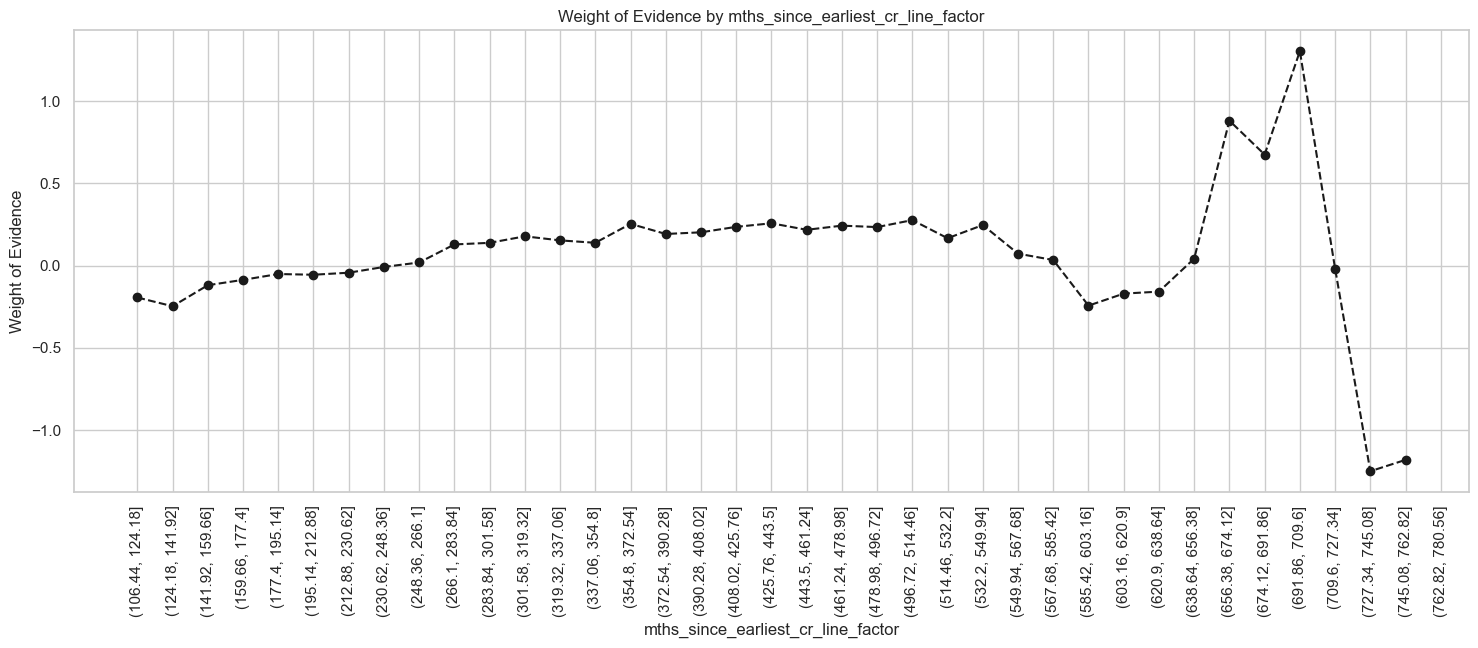

In [89]:
plot_by_woe(df_temp.iloc[6: , : ], 90)
# We plot the weight of evidence values.

In [90]:
# We create the following categories:
# < 140, # 141 - 164, # 165 - 247, # 248 - 270, # 271 - 352, # > 352
df_inputs_prepr['mths_since_earliest_cr_line:<140'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(140)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:141-164'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(140, 165)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:165-247'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(165, 248)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:248-270'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(248, 271)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:271-352'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(271, 353)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:>352'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(353, int(df_inputs_prepr['mths_since_earliest_cr_line'].max()))), 1, 0)

In [91]:
# delinq_2yrs
df_temp = woe_ordered_continuous(df_inputs_prepr, 'delinq_2yrs', df_target_prepr)
# We calculate weight of evidence.
df_temp

,delinq_2yrs,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,306431,0.890758,0.821469,272956.0,33475.0,0.821528,0.820989,0.000657,NaN,NaN,inf
1,1.0,44972,0.891888,0.120559,40110.0,4862.0,0.120721,0.119243,0.012321,0.001130,0.011664,inf
2,2.0,13056,0.887178,0.035000,11583.0,1473.0,0.034862,0.036126,-0.035618,0.004710,0.047938,inf
3,3.0,4510,0.882262,0.012090,3979.0,531.0,0.011976,0.013023,-0.083831,0.004917,0.048214,inf
4,4.0,1895,0.900792,0.005080,1707.0,188.0,0.005138,0.004611,0.108196,0.018530,0.192027,inf
5,5.0,990,0.887879,0.002654,879.0,111.0,0.002646,0.002722,-0.028600,0.012913,0.136796,inf
6,6.0,502,0.894422,0.001346,449.0,53.0,0.001351,0.001300,0.038876,0.006544,0.067476,inf
7,7.0,285,0.877193,0.000764,250.0,35.0,0.000752,0.000858,-0.131742,0.017229,0.170618,inf
8,8.0,145,0.917241,0.000389,133.0,12.0,0.000400,0.000294,0.307587,0.040048,0.439330,inf
9,9.0,83,0.867470,0.000223,72.0,11.0,0.000217,0.000270,-0.219084,0.049771,0.526672,inf


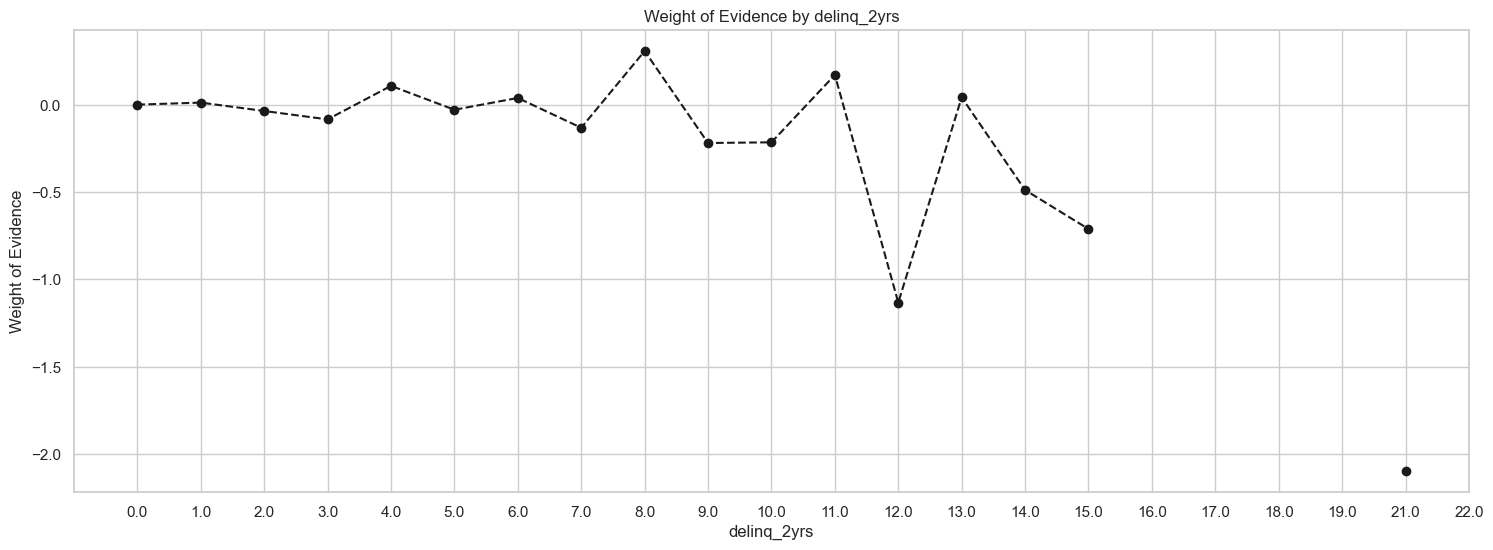

In [92]:
plot_by_woe(df_temp)
# We plot the weight of evidence values.

In [93]:
# Categories: 0, 1-3, >=4
df_inputs_prepr['delinq_2yrs:0'] = np.where((df_inputs_prepr['delinq_2yrs'] == 0), 1, 0)
df_inputs_prepr['delinq_2yrs:1-3'] = np.where((df_inputs_prepr['delinq_2yrs'] >= 1) & (df_inputs_prepr['delinq_2yrs'] <= 3), 1, 0)
df_inputs_prepr['delinq_2yrs:>=4'] = np.where((df_inputs_prepr['delinq_2yrs'] >= 9), 1, 0)

In [94]:
# inq_last_6mths
df_temp = woe_ordered_continuous(df_inputs_prepr, 'inq_last_6mths', df_target_prepr)
# We calculate weight of evidence.
df_temp

C:\Users\lkima\Documents\credit_risk_modelling\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,inq_last_6mths,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,193187,0.908570,0.517889,175524.0,17663.0,0.528283,0.433193,0.198449,NaN,NaN,inf
1,1.0,104049,0.884814,0.278931,92064.0,11985.0,0.277089,0.293937,-0.059027,0.023757,0.257476,inf
2,2.0,46361,0.863679,0.124283,40041.0,6320.0,0.120513,0.155001,-0.251670,0.021135,0.192643,inf
3,3.0,20110,0.841174,0.053910,16916.0,3194.0,0.050913,0.078334,-0.430869,0.022505,0.179199,inf
4,4.0,5772,0.845807,0.015473,4882.0,890.0,0.014694,0.021828,-0.395766,0.004634,0.035103,inf
5,5.0,2218,0.825068,0.005946,1830.0,388.0,0.005508,0.009516,-0.546789,0.020740,0.151023,inf
6,6.0,960,0.792708,0.002574,761.0,199.0,0.002290,0.004881,-0.756527,0.032359,0.209737,inf
7,7.0,153,0.633987,0.000410,97.0,56.0,0.000292,0.001373,-1.548496,0.158721,0.791969,inf
8,8.0,98,0.632653,0.000263,62.0,36.0,0.000187,0.000883,-1.554240,0.001334,0.005744,inf
9,9.0,41,0.609756,0.000110,25.0,16.0,0.000075,0.000392,-1.651568,0.022897,0.097328,inf


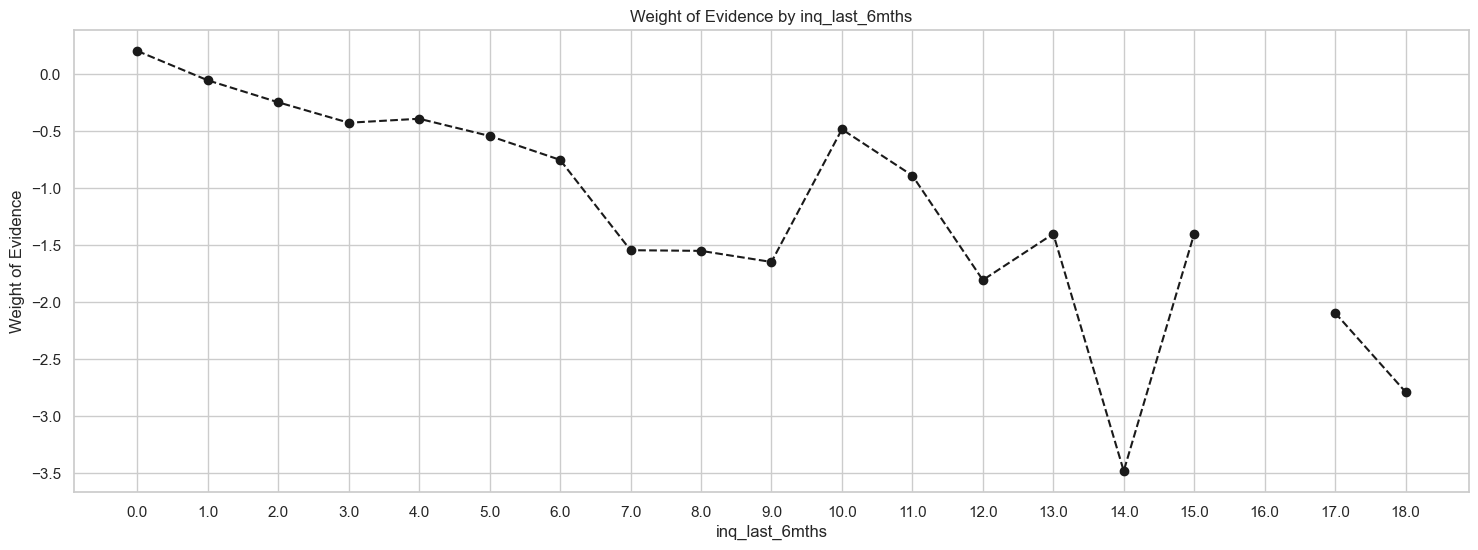

In [95]:
plot_by_woe(df_temp)
# We plot the weight of evidence values.

In [96]:
# Categories: 0, 1 - 2, 3 - 6, > 6
df_inputs_prepr['inq_last_6mths:0'] = np.where((df_inputs_prepr['inq_last_6mths'] == 0), 1, 0)
df_inputs_prepr['inq_last_6mths:1-2'] = np.where((df_inputs_prepr['inq_last_6mths'] >= 1) & (df_inputs_prepr['inq_last_6mths'] <= 2), 1, 0)
df_inputs_prepr['inq_last_6mths:3-6'] = np.where((df_inputs_prepr['inq_last_6mths'] >= 3) & (df_inputs_prepr['inq_last_6mths'] <= 6), 1, 0)
df_inputs_prepr['inq_last_6mths:>6'] = np.where((df_inputs_prepr['inq_last_6mths'] > 6), 1, 0)

In [97]:
# open_acc
df_temp = woe_ordered_continuous(df_inputs_prepr, 'open_acc', df_target_prepr)
# We calculate weight of evidence.
df_temp

C:\Users\lkima\Documents\credit_risk_modelling\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,open_acc,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,32,0.781250,0.000086,25.0,7.0,0.000075,0.000172,-0.824889,NaN,NaN,inf
1,1.0,107,0.887850,0.000287,95.0,12.0,0.000286,0.000294,-0.028885,0.106600,0.796005,inf
2,2.0,1447,0.847270,0.003879,1226.0,221.0,0.003690,0.005420,-0.384506,0.040580,0.355621,inf
3,3.0,4426,0.869860,0.011865,3850.0,576.0,0.011588,0.014127,-0.198134,0.022590,0.186371,inf
4,4.0,10037,0.892199,0.026907,8955.0,1082.0,0.026952,0.026537,0.015546,0.022339,0.213680,inf
...,...,...,...,...,...,...,...,...,...,...,...,...
57,61.0,1,1.000000,0.000003,1.0,0.0,0.000003,0.000000,inf,0.000000,NaN,inf
58,62.0,1,1.000000,0.000003,1.0,0.0,0.000003,0.000000,inf,0.000000,NaN,inf
59,75.0,1,1.000000,0.000003,1.0,0.0,0.000003,0.000000,inf,0.000000,NaN,inf
60,76.0,2,0.000000,0.000005,0.0,2.0,0.000000,0.000049,-inf,1.000000,inf,inf


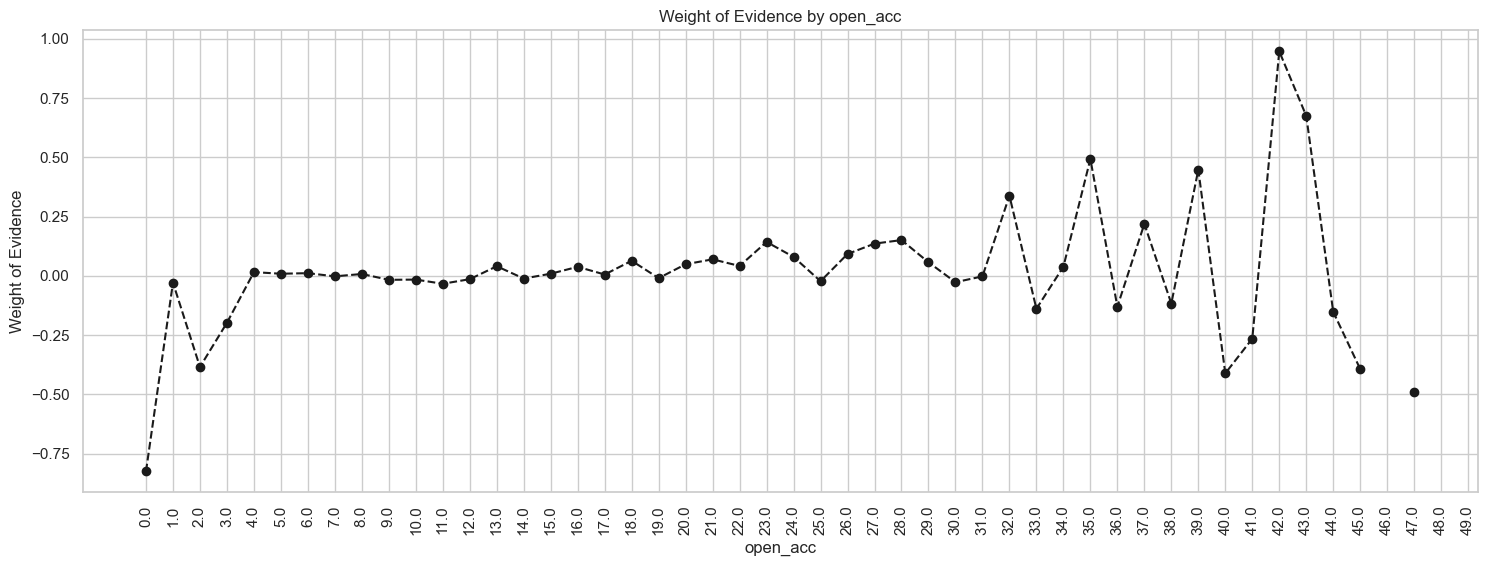

In [98]:
plot_by_woe(df_temp, 90)
# We plot the weight of evidence values.

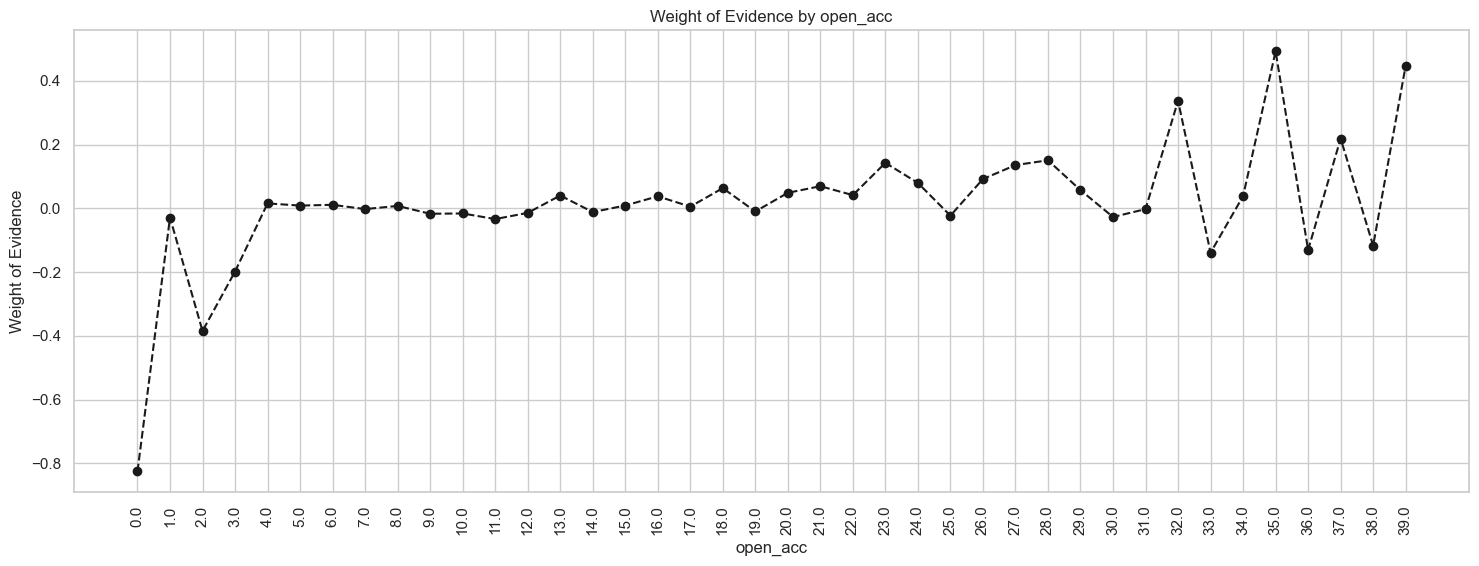

In [99]:
plot_by_woe(df_temp.iloc[ : 40, :], 90)
# We plot the weight of evidence values.


In [100]:
# Categories: '0', '1-3', '4-12', '13-17', '18-22', '23-25', '26-30', '>30'
df_inputs_prepr['open_acc:0'] = np.where((df_inputs_prepr['open_acc'] == 0), 1, 0)
df_inputs_prepr['open_acc:1-3'] = np.where((df_inputs_prepr['open_acc'] >= 1) & (df_inputs_prepr['open_acc'] <= 3), 1, 0)
df_inputs_prepr['open_acc:4-12'] = np.where((df_inputs_prepr['open_acc'] >= 4) & (df_inputs_prepr['open_acc'] <= 12), 1, 0)
df_inputs_prepr['open_acc:13-17'] = np.where((df_inputs_prepr['open_acc'] >= 13) & (df_inputs_prepr['open_acc'] <= 17), 1, 0)
df_inputs_prepr['open_acc:18-22'] = np.where((df_inputs_prepr['open_acc'] >= 18) & (df_inputs_prepr['open_acc'] <= 22), 1, 0)
df_inputs_prepr['open_acc:23-25'] = np.where((df_inputs_prepr['open_acc'] >= 23) & (df_inputs_prepr['open_acc'] <= 25), 1, 0)
df_inputs_prepr['open_acc:26-30'] = np.where((df_inputs_prepr['open_acc'] >= 26) & (df_inputs_prepr['open_acc'] <= 30), 1, 0)
df_inputs_prepr['open_acc:>=31'] = np.where((df_inputs_prepr['open_acc'] >= 31), 1, 0)

In [101]:
# pub_rec
df_temp = woe_ordered_continuous(df_inputs_prepr, 'pub_rec', df_target_prepr)
# We calculate weight of evidence.
df_temp

,pub_rec,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,323916,0.889678,0.868342,288181.0,35735.0,0.867351,0.876416,-0.010397,NaN,NaN,inf
1,1.0,42470,0.895409,0.113852,38028.0,4442.0,0.114455,0.108942,0.049363,0.005730,0.059760,inf
2,2.0,4476,0.907060,0.011999,4060.0,416.0,0.012220,0.010203,0.180398,0.011651,0.131035,inf
3,3.0,1288,0.915373,0.003453,1179.0,109.0,0.003548,0.002673,0.283219,0.008313,0.102821,inf
4,4.0,430,0.909302,0.001153,391.0,39.0,0.001177,0.000956,0.207291,0.006070,0.075928,inf
5,5.0,236,0.906780,0.000633,214.0,22.0,0.000644,0.000540,0.177078,0.002523,0.030212,inf
6,6.0,111,0.945946,0.000298,105.0,6.0,0.000316,0.000147,0.764346,0.039166,0.587267,inf
7,7.0,44,0.954545,0.000118,42.0,2.0,0.000126,0.000049,0.946667,0.008600,0.182322,inf
8,8.0,23,0.956522,0.000062,22.0,1.0,0.000066,0.000025,0.993187,0.001976,0.046520,inf
9,9.0,13,0.846154,0.000035,11.0,2.0,0.000033,0.000049,-0.393107,0.110368,1.386294,inf


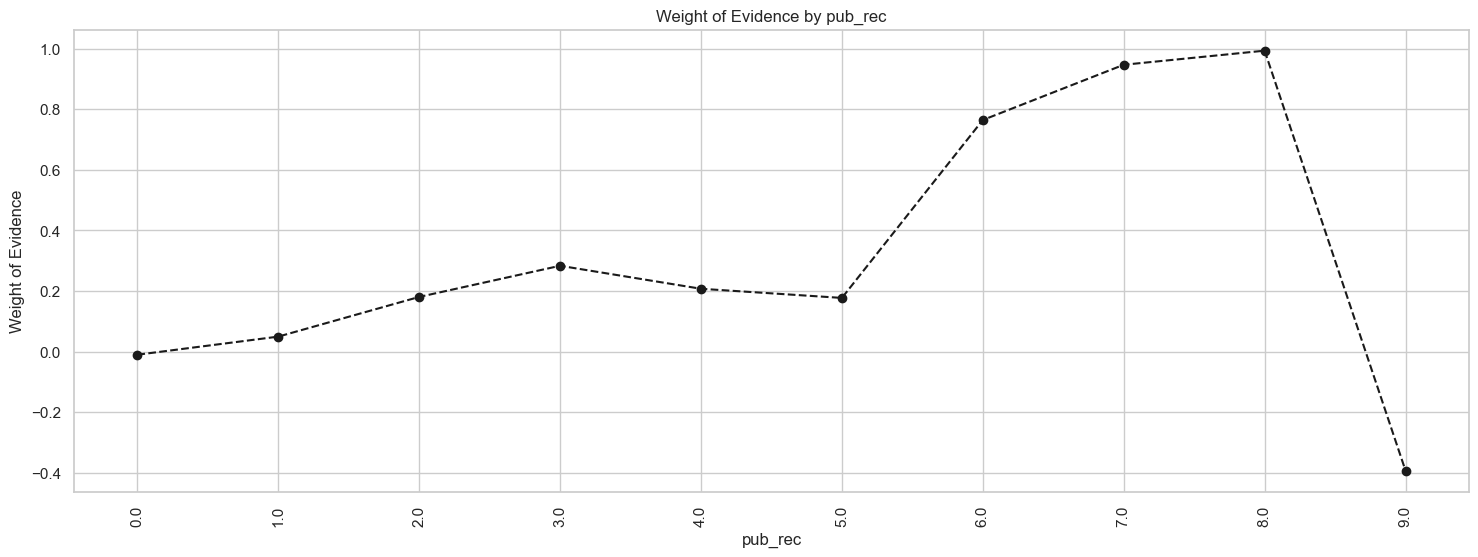

In [102]:
plot_by_woe(df_temp, 90)
# We plot the weight of evidence values.

In [103]:
# Categories '0-2', '3-4', '>=5'
df_inputs_prepr['pub_rec:0-2'] = np.where((df_inputs_prepr['pub_rec'] >= 0) & (df_inputs_prepr['pub_rec'] <= 2), 1, 0)
df_inputs_prepr['pub_rec:3-4'] = np.where((df_inputs_prepr['pub_rec'] >= 3) & (df_inputs_prepr['pub_rec'] <= 4), 1, 0)
df_inputs_prepr['pub_rec:>=5'] = np.where((df_inputs_prepr['pub_rec'] >= 5), 1, 0)

In [104]:
# total_acc
df_inputs_prepr['total_acc_factor'] = pd.cut(df_inputs_prepr['total_acc'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'total_acc_factor', df_target_prepr)
# We calculate weight of evidence.
df_temp

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,total_acc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.156, 3.12]",487,0.804928,0.001306,392.0,95.0,0.001180,0.002330,-0.680470,NaN,NaN,inf
1,"(3.12, 6.24]",6006,0.864136,0.016101,5190.0,816.0,0.015621,0.020013,-0.247780,0.059208,0.432690,inf
2,"(6.24, 9.36]",14915,0.873684,0.039984,13031.0,1884.0,0.039220,0.046206,-0.163921,0.009548,0.083859,inf
3,"(9.36, 12.48]",25131,0.880068,0.067370,22117.0,3014.0,0.066567,0.073920,-0.104777,0.006384,0.059144,inf
4,"(12.48, 15.6]",33516,0.881310,0.089848,29538.0,3978.0,0.088902,0.097562,-0.092957,0.001242,0.011820,inf
5,"(15.6, 18.72]",38785,0.886683,0.103973,34390.0,4395.0,0.103505,0.107789,-0.040557,0.005373,0.052400,inf
6,"(18.72, 21.84]",40731,0.887751,0.109190,36159.0,4572.0,0.108829,0.112130,-0.029880,0.001068,0.010677,inf
7,"(21.84, 24.96]",40178,0.892404,0.107708,35855.0,4323.0,0.107914,0.106023,0.017678,0.004652,0.047558,inf
8,"(24.96, 28.08]",47480,0.894313,0.127283,42462.0,5018.0,0.127800,0.123069,0.037723,0.001910,0.020045,inf
9,"(28.08, 31.2]",29697,0.898811,0.079611,26692.0,3005.0,0.080336,0.073699,0.086231,0.004498,0.048508,inf


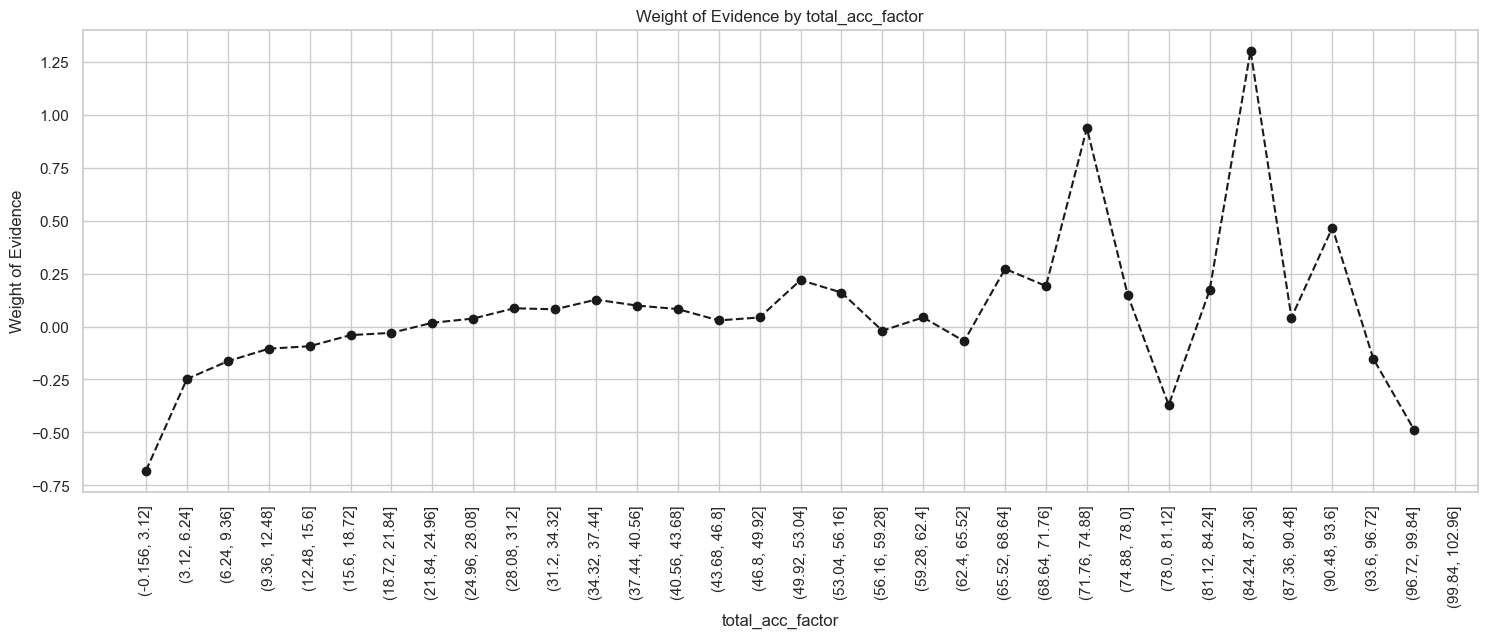

In [105]:
plot_by_woe(df_temp, 90)
# We plot the weight of evidence values.

In [106]:
# Categories: '<=27', '28-51', '>51'
df_inputs_prepr['total_acc:<=27'] = np.where((df_inputs_prepr['total_acc'] <= 27), 1, 0)
df_inputs_prepr['total_acc:28-51'] = np.where((df_inputs_prepr['total_acc'] >= 28) & (df_inputs_prepr['total_acc'] <= 51), 1, 0)
df_inputs_prepr['total_acc:>=52'] = np.where((df_inputs_prepr['total_acc'] >= 52), 1, 0)

In [107]:
# acc_now_delinq
df_temp = woe_ordered_continuous(df_inputs_prepr, 'acc_now_delinq', df_target_prepr)
# We calculate weight of evidence.
df_temp

,acc_now_delinq,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,371660,0.890655,0.996333,331021.0,40639.0,0.996289,0.996689,-0.000401,NaN,NaN,inf
1,1.0,1286,0.902799,0.003447,1161.0,125.0,0.003494,0.003066,0.130868,0.012144,0.131270,inf
2,2.0,68,0.897059,0.000182,61.0,7.0,0.000184,0.000172,0.067109,0.005741,0.063760,inf
3,3.0,9,0.777778,0.000024,7.0,2.0,0.000021,0.000049,-0.845092,0.119281,0.912201,inf
4,4.0,3,1.000000,0.000008,3.0,0.0,0.000009,0.000000,inf,0.222222,inf,inf
5,5.0,2,0.500000,0.000005,1.0,1.0,0.000003,0.000025,-2.097855,0.500000,inf,inf


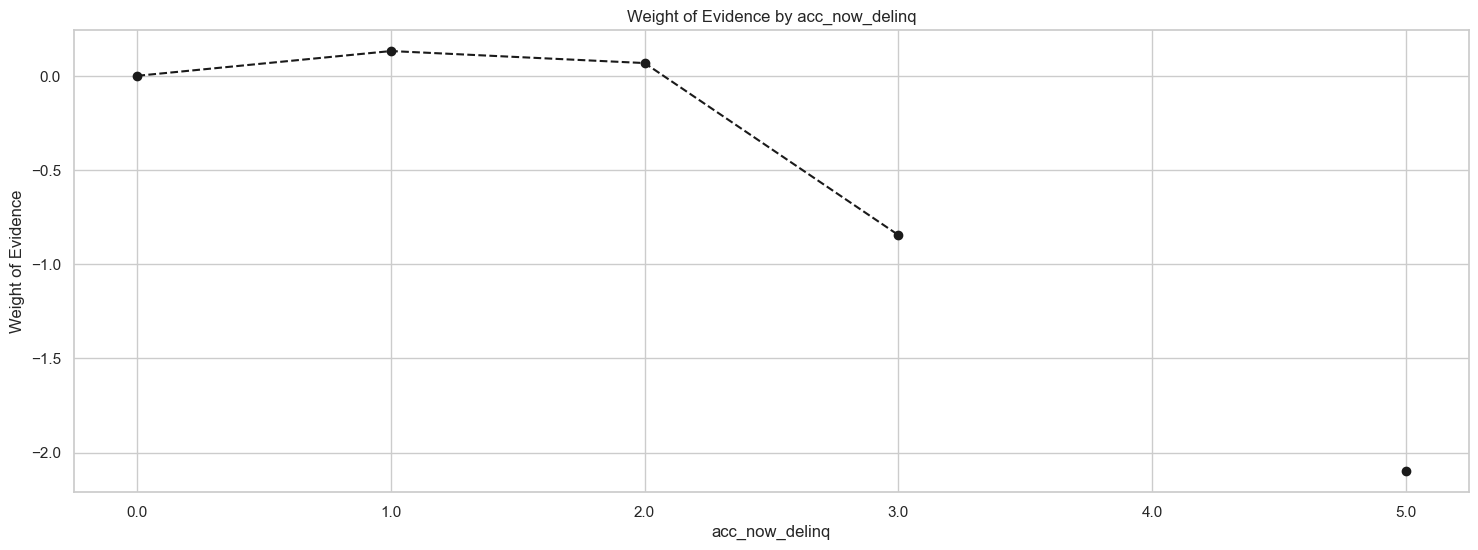

In [108]:
plot_by_woe(df_temp)
# We plot the weight of evidence values.

In [109]:
# Categories: '0', '>=1'
df_inputs_prepr['acc_now_delinq:0'] = np.where((df_inputs_prepr['acc_now_delinq'] == 0), 1, 0)
df_inputs_prepr['acc_now_delinq:>=1'] = np.where((df_inputs_prepr['acc_now_delinq'] >= 1), 1, 0)

In [110]:
# total_rev_hi_lim
df_inputs_prepr['total_rev_hi_lim_factor'] = pd.cut(df_inputs_prepr['total_rev_hi_lim'], 2000)
# Here we do fine-classing: using the 'cut' method, we split the variable into 2000 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'total_rev_hi_lim_factor', df_target_prepr)
# We calculate weight of evidence.
df_temp

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
C:\Users\lkima\Documents\credit_risk_modelling\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)

,total_rev_hi_lim_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-9999.999, 5000.0]",19466,0.866485,0.052184,16867.0,2599.0,0.050765,0.063742,-0.227623,NaN,NaN,inf
1,"(5000.0, 9999.999]",52690,0.876011,0.141249,46157.0,6533.0,0.138921,0.160225,-0.142673,0.009525,0.084950,inf
2,"(9999.999, 14999.998]",59525,0.880487,0.159572,52411.0,7114.0,0.157744,0.174474,-0.100803,0.004477,0.041869,inf
3,"(14999.998, 19999.998]",51408,0.877334,0.137813,45102.0,6306.0,0.135746,0.154657,-0.130430,0.003153,0.029627,inf
4,"(19999.998, 24999.997]",41624,0.886436,0.111584,36897.0,4727.0,0.111051,0.115932,-0.043016,0.009101,0.087414,inf
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,"(9974999.002, 9979999.002]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf
1996,"(9979999.002, 9984999.002]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf
1997,"(9984999.002, 9989999.001]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf
1998,"(9989999.001, 9994999.0]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf


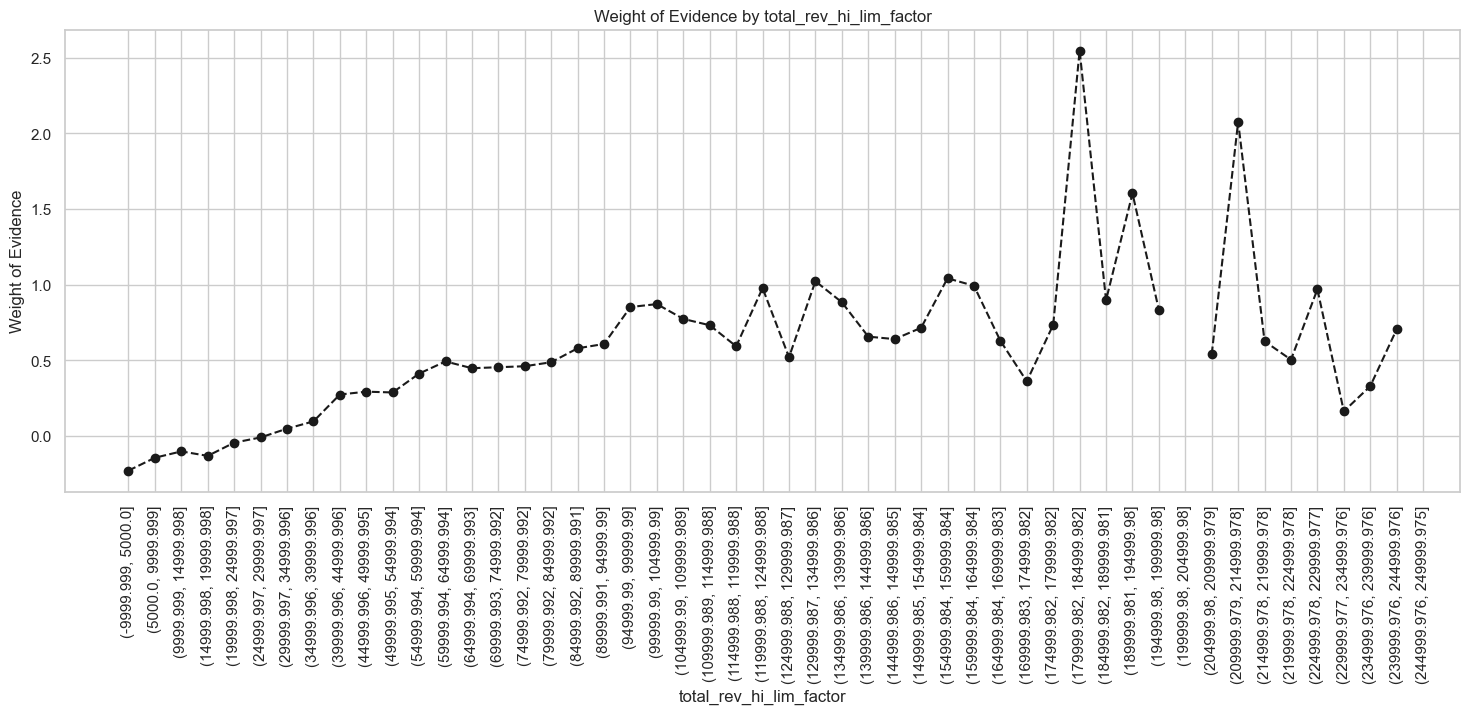

In [111]:
plot_by_woe(df_temp.iloc[: 50, : ], 90)
# We plot the weight of evidence values.

In [112]:
# Categories
# '<=5K', '5K-10K', '10K-20K', '20K-30K', '30K-40K', '40K-55K', '55K-95K', '>95K'
df_inputs_prepr['total_rev_hi_lim:<=5K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] <= 5000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:5K-10K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 5000) & (df_inputs_prepr['total_rev_hi_lim'] <= 10000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:10K-20K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 10000) & (df_inputs_prepr['total_rev_hi_lim'] <= 20000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:20K-30K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 20000) & (df_inputs_prepr['total_rev_hi_lim'] <= 30000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:30K-40K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 30000) & (df_inputs_prepr['total_rev_hi_lim'] <= 40000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:40K-55K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 40000) & (df_inputs_prepr['total_rev_hi_lim'] <= 55000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:55K-95K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 55000) & (df_inputs_prepr['total_rev_hi_lim'] <= 95000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:>95K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 95000), 1, 0)

In [113]:
# installment
df_inputs_prepr['installment_factor'] = pd.cut(df_inputs_prepr['installment'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'installment_factor', df_target_prepr)
# We calculate weight of evidence.
df_temp

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,installment_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(14.276, 43.556]",1841,0.897338,0.004935,1652.0,189.0,0.004972,0.004635,0.070140,NaN,NaN,0.012927
1,"(43.556, 71.443]",4889,0.903661,0.013106,4418.0,471.0,0.013297,0.011551,0.140729,0.006323,0.070589,0.012927
2,"(71.443, 99.329]",6875,0.892945,0.018430,6139.0,736.0,0.018477,0.018051,0.023332,0.010716,0.117397,0.012927
3,"(99.329, 127.216]",9145,0.891525,0.024516,8153.0,992.0,0.024538,0.024329,0.008563,0.001420,0.014769,0.012927
4,"(127.216, 155.102]",10099,0.895534,0.027073,9044.0,1055.0,0.027220,0.025874,0.050706,0.004009,0.042143,0.012927
5,"(155.102, 182.988]",16786,0.895449,0.044999,15031.0,1755.0,0.045239,0.043042,0.049791,0.000086,0.000915,0.012927
6,"(182.988, 210.875]",17047,0.905086,0.045699,15429.0,1618.0,0.046437,0.039682,0.157203,0.009637,0.107412,0.012927
7,"(210.875, 238.761]",15114,0.900225,0.040517,13606.0,1508.0,0.040951,0.036984,0.101871,0.004861,0.055331,0.012927
8,"(238.761, 266.648]",18717,0.899984,0.050176,16845.0,1872.0,0.050699,0.045912,0.099191,0.000241,0.002680,0.012927
9,"(266.648, 294.534]",20121,0.890214,0.053940,17912.0,2209.0,0.053911,0.054177,-0.004924,0.009770,0.104116,0.012927


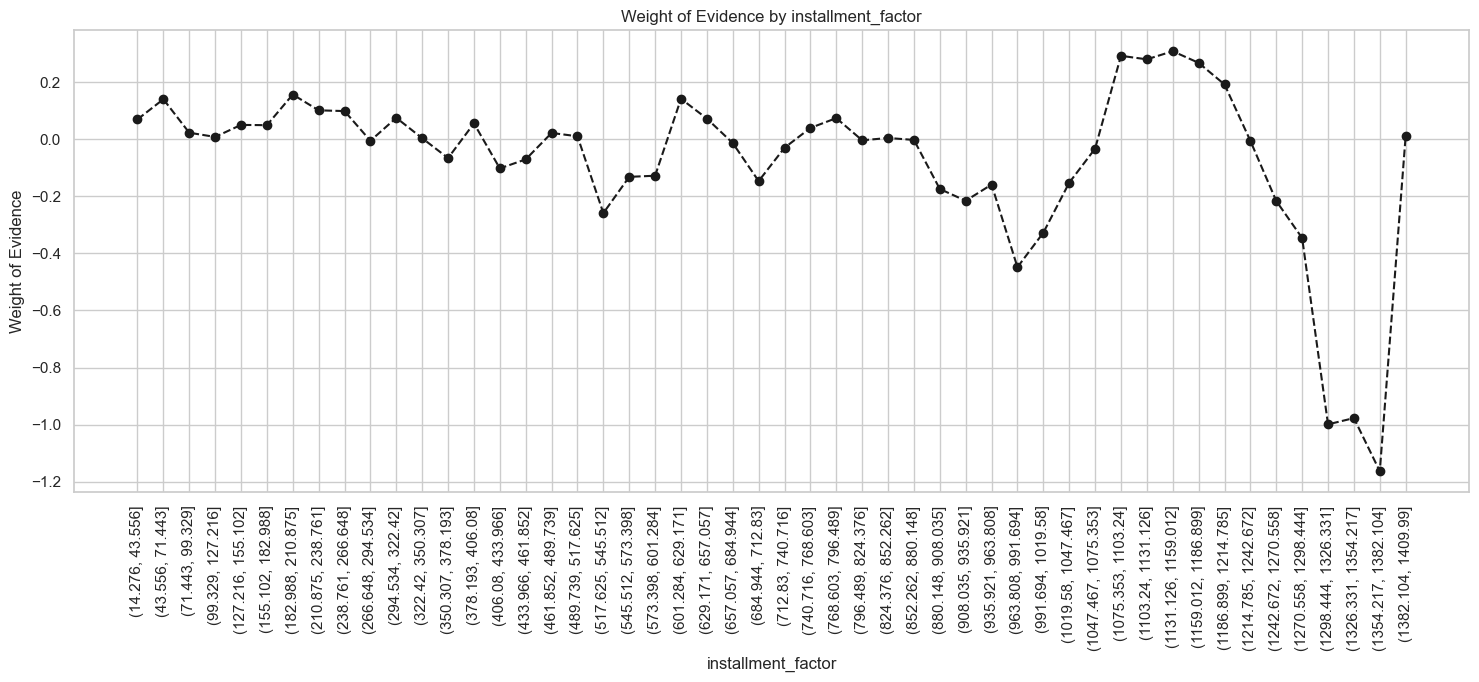

In [114]:
plot_by_woe(df_temp, 90)
# We plot the weight of evidence values.

In [115]:
# annual_inc
df_inputs_prepr['annual_inc_factor'] = pd.cut(df_inputs_prepr['annual_inc'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'annual_inc_factor', df_target_prepr)
# We calculate weight of evidence.
df_temp

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-5602.104, 151858.08]",356633,0.889079,0.956049,317075.0,39558.0,0.954315,0.970177,-0.016485,NaN,NaN,inf
1,"(151858.08, 301820.16]",14796,0.925047,0.039665,13687.0,1109.0,0.041194,0.027199,0.415133,0.035968,0.431617,inf
2,"(301820.16, 451782.24]",1076,0.930297,0.002885,1001.0,75.0,0.003013,0.001839,0.493412,0.005250,0.078279,inf
3,"(451782.24, 601744.32]",291,0.941581,0.000780,274.0,17.0,0.000825,0.000417,0.682060,0.011283,0.188648,inf
4,"(601744.32, 751706.4]",96,0.906250,0.000257,87.0,9.0,0.000262,0.000221,0.170828,0.035331,0.511231,inf
5,"(751706.4, 901668.48]",59,0.932203,0.000158,55.0,4.0,0.000166,0.000098,0.523184,0.025953,0.352355,inf
6,"(901668.48, 1051630.56]",30,0.966667,0.000080,29.0,1.0,0.000087,0.000025,1.269441,0.034463,0.746257,inf
7,"(1051630.56, 1201592.64]",19,1.000000,0.000051,19.0,0.0,0.000057,0.000000,inf,0.033333,inf,inf
8,"(1201592.64, 1351554.72]",7,0.857143,0.000019,6.0,1.0,0.000018,0.000025,-0.306096,0.142857,inf,inf
9,"(1351554.72, 1501516.8]",5,1.000000,0.000013,5.0,0.0,0.000015,0.000000,inf,0.142857,inf,inf


In [116]:
df_inputs_prepr['annual_inc_factor'] = pd.cut(df_inputs_prepr['annual_inc'], 100)
# Here we do fine-classing: using the 'cut' method, we split the variable into 100 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'annual_inc_factor', df_target_prepr)
# We calculate weight of evidence.
df_temp

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-5602.104, 76877.04]",245053,0.877480,0.656929,215029.0,30024.0,0.647183,0.736352,-0.129079,NaN,NaN,inf
1,"(76877.04, 151858.08]",111580,0.914555,0.299120,102046.0,9534.0,0.307132,0.233825,0.272704,0.037075,0.401783,inf
2,"(151858.08, 226839.12]",11948,0.924590,0.032030,11047.0,901.0,0.033249,0.022097,0.408554,0.010035,0.135850,inf
3,"(226839.12, 301820.16]",2848,0.926966,0.007635,2640.0,208.0,0.007946,0.005101,0.443141,0.002376,0.034587,inf
4,"(301820.16, 376801.2]",689,0.925980,0.001847,638.0,51.0,0.001920,0.001251,0.428658,0.000987,0.014483,inf
...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(7125094.8, 7200075.84]",1,1.000000,0.000003,1.0,0.0,0.000003,0.000000,inf,NaN,NaN,inf
96,"(7200075.84, 7275056.88]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf
97,"(7275056.88, 7350037.92]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf
98,"(7350037.92, 7425018.96]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf


In [117]:
# Initial examination shows that there are too few individuals with large income and too many with small income.
# Hence, we are going to have one category for more than 150K, and we are going to apply our approach to determine
# the categories of everyone with 140k or less.
df_inputs_prepr_temp = df_inputs_prepr.loc[df_inputs_prepr['annual_inc'] <= 140000, : ]
#loan_data_temp = loan_data_temp.reset_index(drop = True)
#df_inputs_prepr_temp

In [118]:
df_inputs_prepr_temp["annual_inc_factor"] = pd.cut(df_inputs_prepr_temp['annual_inc'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'annual_inc_factor', df_target_prepr[df_inputs_prepr_temp.index])
# We calculate weight of evidence.
df_temp

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\3762046214.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inputs_prepr_temp["annual_inc_factor"] = pd.cut(df_inputs_prepr_temp['annual_inc'], 50)
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to Tr

,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(1757.896, 4658.08]",10,0.800000,0.000028,8.0,2.0,0.000026,0.000051,-0.689734,NaN,NaN,0.047687
1,"(4658.08, 7420.16]",40,0.800000,0.000114,32.0,8.0,0.000103,0.000205,-0.689734,0.000000,0.000000,0.047687
2,"(7420.16, 10182.24]",298,0.865772,0.000849,258.0,40.0,0.000828,0.001023,-0.211948,0.065772,0.477786,0.047687
3,"(10182.24, 12944.32]",529,0.810964,0.001508,429.0,100.0,0.001376,0.002557,-0.619742,0.054808,0.407793,0.047687
4,"(12944.32, 15706.4]",1222,0.839607,0.003483,1026.0,196.0,0.003291,0.005012,-0.420720,0.028643,0.199022,0.047687
5,"(15706.4, 18468.48]",1550,0.848387,0.004417,1315.0,235.0,0.004218,0.006009,-0.354022,0.008780,0.066698,0.047687
6,"(18468.48, 21230.56]",2960,0.853378,0.008436,2526.0,434.0,0.008102,0.011098,-0.314681,0.004991,0.039341,0.047687
7,"(21230.56, 23992.64]",2569,0.844297,0.007321,2169.0,400.0,0.006957,0.010229,-0.385471,0.009081,0.070791,0.047687
8,"(23992.64, 26754.72]",7104,0.853744,0.020246,6065.0,1039.0,0.019453,0.026569,-0.311752,0.009447,0.073719,0.047687
9,"(26754.72, 29516.8]",5608,0.858238,0.015982,4813.0,795.0,0.015437,0.020329,-0.275295,0.004494,0.036458,0.047687


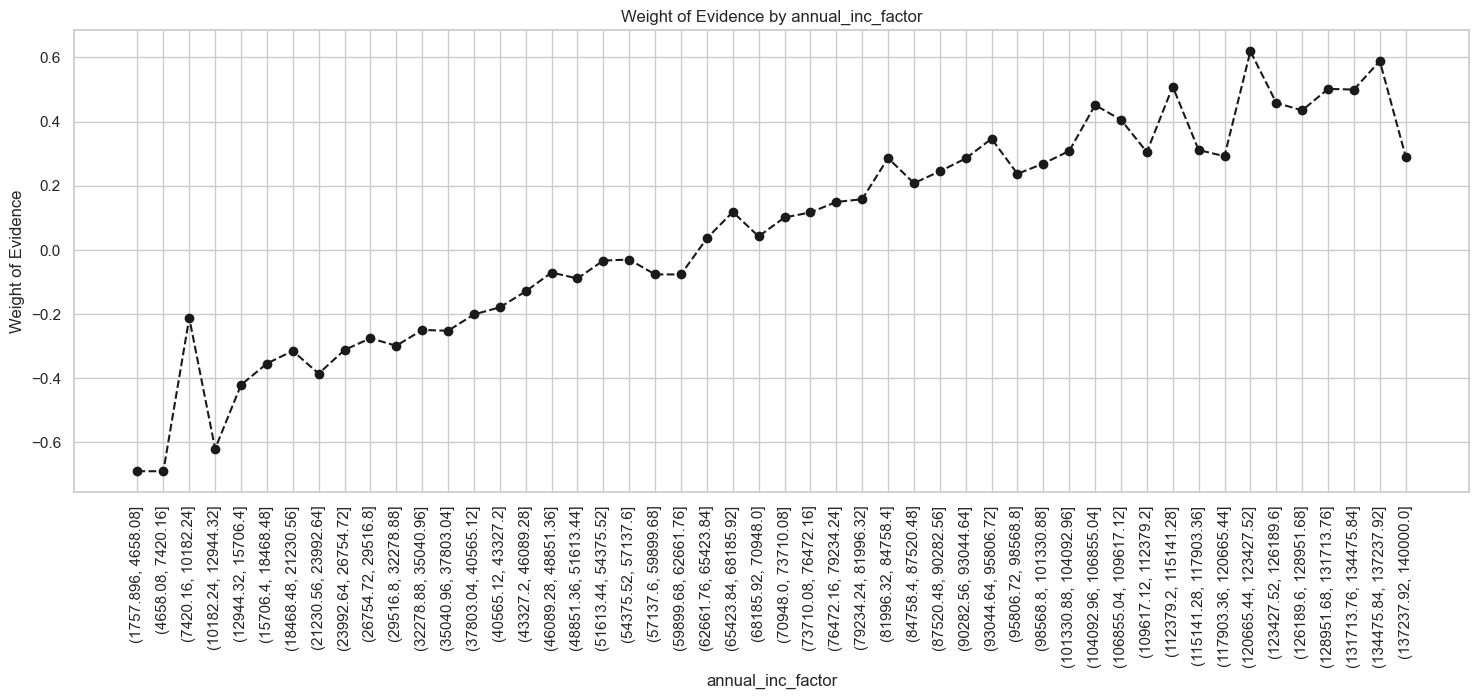

In [119]:
plot_by_woe(df_temp, 90)
# We plot the weight of evidence values.

In [120]:
# WoE is monotonically decreasing with income, so we split income in 10 equal categories, each with width of 15k.
df_inputs_prepr['annual_inc:<20K'] = np.where((df_inputs_prepr['annual_inc'] <= 20000), 1, 0)
df_inputs_prepr['annual_inc:20K-30K'] = np.where((df_inputs_prepr['annual_inc'] > 20000) & (df_inputs_prepr['annual_inc'] <= 30000), 1, 0)
df_inputs_prepr['annual_inc:30K-40K'] = np.where((df_inputs_prepr['annual_inc'] > 30000) & (df_inputs_prepr['annual_inc'] <= 40000), 1, 0)
df_inputs_prepr['annual_inc:40K-50K'] = np.where((df_inputs_prepr['annual_inc'] > 40000) & (df_inputs_prepr['annual_inc'] <= 50000), 1, 0)
df_inputs_prepr['annual_inc:50K-60K'] = np.where((df_inputs_prepr['annual_inc'] > 50000) & (df_inputs_prepr['annual_inc'] <= 60000), 1, 0)
df_inputs_prepr['annual_inc:60K-70K'] = np.where((df_inputs_prepr['annual_inc'] > 60000) & (df_inputs_prepr['annual_inc'] <= 70000), 1, 0)
df_inputs_prepr['annual_inc:70K-80K'] = np.where((df_inputs_prepr['annual_inc'] > 70000) & (df_inputs_prepr['annual_inc'] <= 80000), 1, 0)
df_inputs_prepr['annual_inc:80K-90K'] = np.where((df_inputs_prepr['annual_inc'] > 80000) & (df_inputs_prepr['annual_inc'] <= 90000), 1, 0)
df_inputs_prepr['annual_inc:90K-100K'] = np.where((df_inputs_prepr['annual_inc'] > 90000) & (df_inputs_prepr['annual_inc'] <= 100000), 1, 0)
df_inputs_prepr['annual_inc:100K-120K'] = np.where((df_inputs_prepr['annual_inc'] > 100000) & (df_inputs_prepr['annual_inc'] <= 120000), 1, 0)
df_inputs_prepr['annual_inc:120K-140K'] = np.where((df_inputs_prepr['annual_inc'] > 120000) & (df_inputs_prepr['annual_inc'] <= 140000), 1, 0)
df_inputs_prepr['annual_inc:>140K'] = np.where((df_inputs_prepr['annual_inc'] > 140000), 1, 0)

In [121]:
# mths_since_last_delinq
# We have to create one category for missing values and do fine and coarse classing for the rest.
df_inputs_prepr_temp = df_inputs_prepr[pd.notnull(df_inputs_prepr['mths_since_last_delinq'])]
df_inputs_prepr_temp['mths_since_last_delinq_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_delinq'], 50)
df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'mths_since_last_delinq_factor', df_target_prepr[df_inputs_prepr_temp.index])
# We calculate weight of evidence.
df_temp

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\102080819.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inputs_prepr_temp['mths_since_last_delinq_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_delinq'], 50)
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:5: FutureWarning: The default of observed=False is deprecated an

,mths_since_last_delinq_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.188, 3.76]",5255,0.873834,0.030437,4592.0,663.0,0.029820,0.035534,-0.175336,NaN,NaN,inf
1,"(3.76, 7.52]",11070,0.884914,0.064118,9796.0,1274.0,0.063613,0.068282,-0.070820,0.011080,0.104517,inf
2,"(7.52, 11.28]",13371,0.891257,0.077445,11917.0,1454.0,0.077387,0.077929,-0.006985,0.006343,0.063835,inf
3,"(11.28, 15.04]",13272,0.885398,0.076872,11751.0,1521.0,0.076309,0.081520,-0.066062,0.005859,0.059077,inf
4,"(15.04, 18.8]",9267,0.896622,0.053675,8309.0,958.0,0.053957,0.051345,0.049615,0.011225,0.115676,inf
5,"(18.8, 22.56]",11640,0.892612,0.067419,10390.0,1250.0,0.067471,0.066995,0.007068,0.004011,0.042547,inf
6,"(22.56, 26.32]",10918,0.895860,0.063237,9781.0,1137.0,0.063516,0.060939,0.041416,0.003248,0.034348,inf
7,"(26.32, 30.08]",10557,0.894099,0.061146,9439.0,1118.0,0.061295,0.059921,0.022677,0.001761,0.018740,inf
8,"(30.08, 33.84]",7548,0.899974,0.043718,6793.0,755.0,0.044112,0.040465,0.086298,0.005875,0.063622,inf
9,"(33.84, 37.6]",9720,0.899588,0.056299,8744.0,976.0,0.056782,0.052310,0.082028,0.000385,0.004270,inf


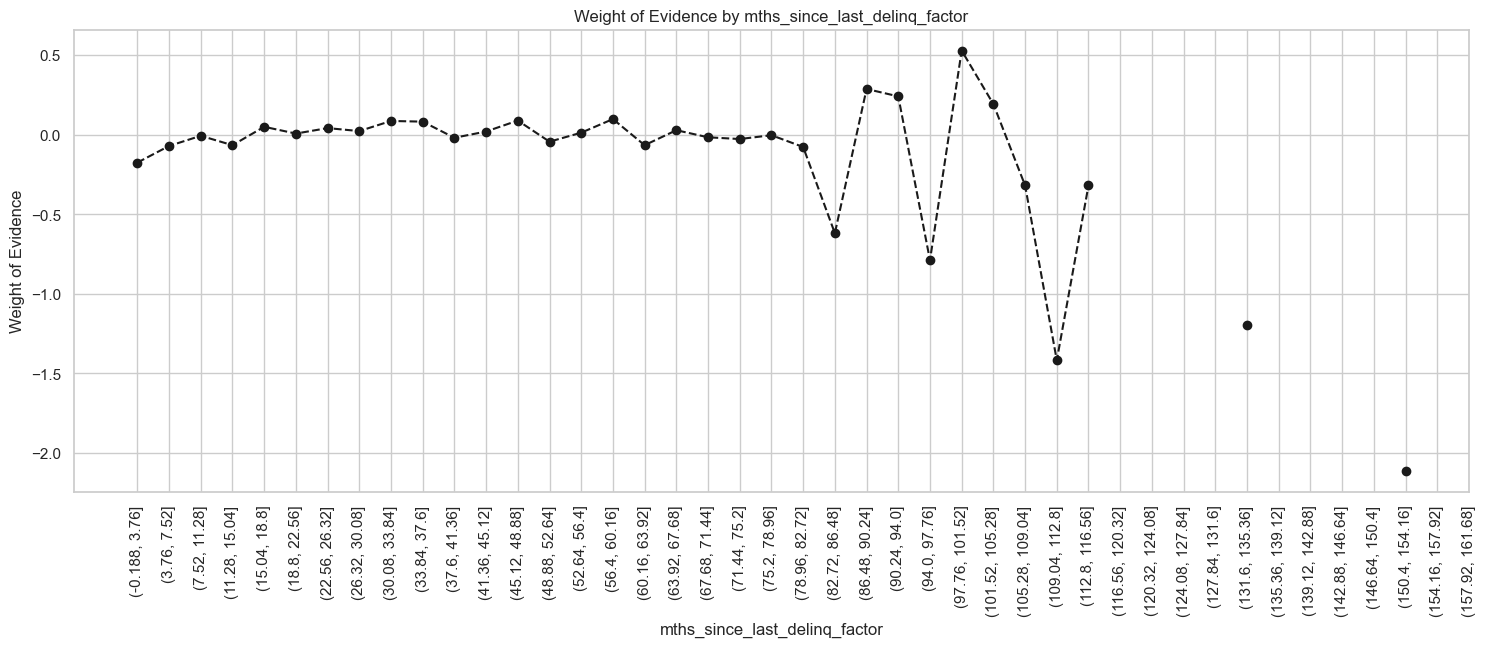

In [122]:
plot_by_woe(df_temp, 90)
# We plot the weight of evidence values.

In [123]:
# Categories: Missing, 0-3, 4-30, 31-56, >=57
df_inputs_prepr['mths_since_last_delinq:Missing'] = np.where((df_inputs_prepr['mths_since_last_delinq'].isnull()), 1, 0)
df_inputs_prepr['mths_since_last_delinq:0-3'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 0) & (df_inputs_prepr['mths_since_last_delinq'] <= 3), 1, 0)
df_inputs_prepr['mths_since_last_delinq:4-30'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 4) & (df_inputs_prepr['mths_since_last_delinq'] <= 30), 1, 0)
df_inputs_prepr['mths_since_last_delinq:31-56'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 31) & (df_inputs_prepr['mths_since_last_delinq'] <= 56), 1, 0)
df_inputs_prepr['mths_since_last_delinq:>=57'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 57), 1, 0)

In [124]:
# dti
df_inputs_prepr['dti_factor'] = pd.cut(df_inputs_prepr['dti'], 100)
# Here we do fine-classing: using the 'cut' method, we split the variable into 100 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr, 'dti_factor', df_target_prepr)
# We calculate weight of evidence.
df_temp

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)


,dti_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.04, 0.4]",749,0.878505,0.002008,658.0,91.0,0.001980,0.002232,-0.119510,NaN,NaN,0.029017
1,"(0.4, 0.8]",788,0.922589,0.002112,727.0,61.0,0.002188,0.001496,0.380198,0.044084,0.499707,0.029017
2,"(0.8, 1.2]",921,0.896851,0.002469,826.0,95.0,0.002486,0.002330,0.064863,0.025738,0.315335,0.029017
3,"(1.2, 1.6]",1045,0.907177,0.002801,948.0,97.0,0.002853,0.002379,0.181788,0.010326,0.116926,0.029017
4,"(1.6, 2.0]",1172,0.901877,0.003142,1057.0,115.0,0.003181,0.002820,0.120403,0.005300,0.061386,0.029017
...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(37.991, 38.39]",213,0.845070,0.000571,180.0,33.0,0.000542,0.000809,-0.401406,0.051481,0.463035,0.029017
96,"(38.39, 38.79]",176,0.869318,0.000472,153.0,23.0,0.000460,0.000564,-0.202911,0.024248,0.198494,0.029017
97,"(38.79, 39.19]",195,0.871795,0.000523,170.0,25.0,0.000512,0.000613,-0.180933,0.002477,0.021979,0.029017
98,"(39.19, 39.59]",178,0.904494,0.000477,161.0,17.0,0.000485,0.000417,0.150336,0.032700,0.331268,0.029017


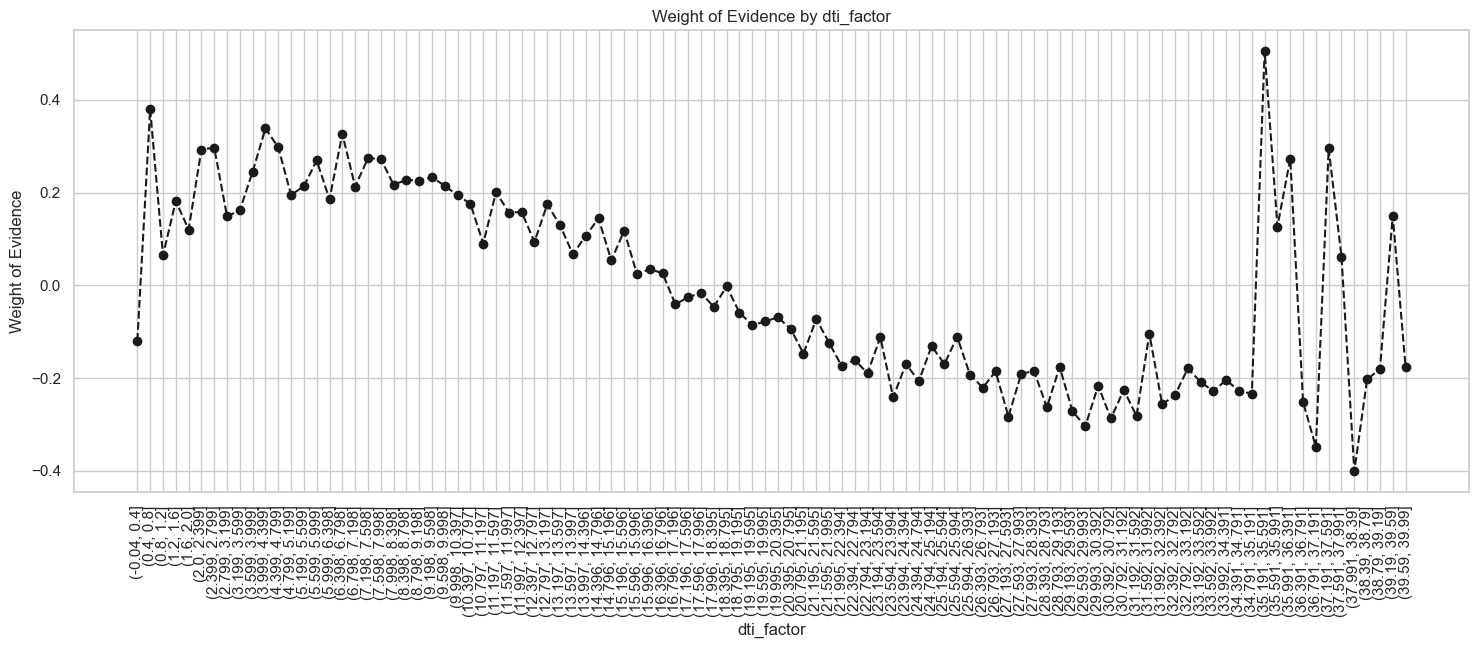

In [125]:
plot_by_woe(df_temp, 90)
# We plot the weight of evidence values.

In [126]:
# Similarly to income, initial examination shows that most values are lower than 200.
# Hence, we are going to have one category for more than 35, and we are going to apply our approach to determine
# the categories of everyone with 150k or less.
df_inputs_prepr_temp = df_inputs_prepr.loc[df_inputs_prepr['dti'] <= 35, : ]

In [127]:
df_inputs_prepr_temp['dti_factor'] = pd.cut(df_inputs_prepr_temp['dti'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'dti_factor', df_target_prepr[df_inputs_prepr_temp.index])
# We calculate weight of evidence.
df_temp

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\99465213.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inputs_prepr_temp['dti_factor'] = pd.cut(df_inputs_prepr_temp['dti'], 50)
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future v

,dti_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.035, 0.7]",1346,0.898217,0.003636,1209.0,137.0,0.003667,0.003386,0.079625,NaN,NaN,0.027802
1,"(0.7, 1.4]",1664,0.897837,0.004495,1494.0,170.0,0.004531,0.004202,0.075471,0.000380,0.004154,0.027802
2,"(1.4, 2.1]",2003,0.913130,0.005411,1829.0,174.0,0.005547,0.004301,0.254527,0.015294,0.179055,0.027802
3,"(2.1, 2.8]",2575,0.912621,0.006956,2350.0,225.0,0.007127,0.005561,0.248128,0.000509,0.006399,0.027802
4,"(2.8, 3.5]",3159,0.907249,0.008534,2866.0,293.0,0.008692,0.007242,0.182557,0.005372,0.065570,0.027802
5,"(3.5, 4.2]",3826,0.915055,0.010336,3501.0,325.0,0.010618,0.008033,0.279036,0.007806,0.096479,0.027802
6,"(4.2, 4.9]",4618,0.913382,0.012475,4218.0,400.0,0.012793,0.009887,0.257709,0.001672,0.021327,0.027802
7,"(4.9, 5.6]",5340,0.909738,0.014426,4858.0,482.0,0.014734,0.011913,0.212495,0.003645,0.045214,0.027802
8,"(5.6, 6.3]",5937,0.910898,0.016038,5408.0,529.0,0.016402,0.013075,0.226704,0.001160,0.014208,0.027802
9,"(6.3, 7.0]",6566,0.913037,0.017738,5995.0,571.0,0.018182,0.014113,0.253349,0.002139,0.026646,0.027802


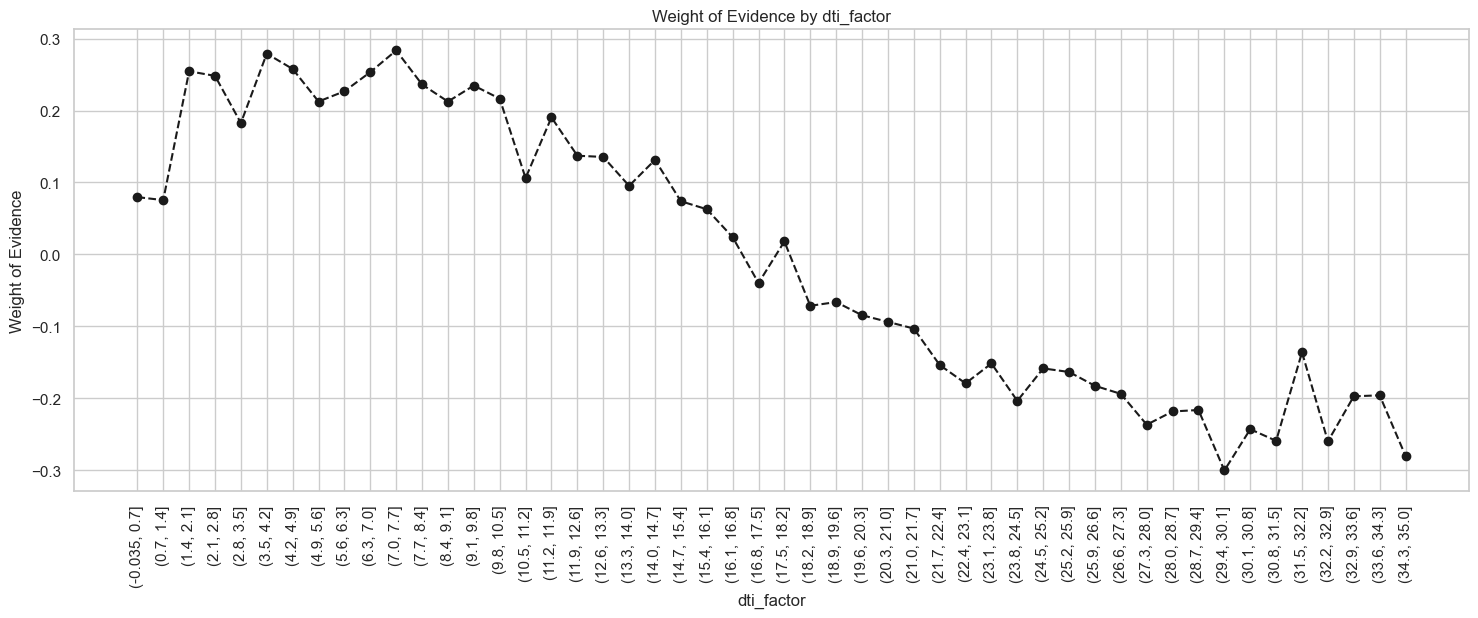

In [128]:
plot_by_woe(df_temp, 90)
# We plot the weight of evidence values.

In [129]:
# Categories:
df_inputs_prepr['dti:<=1.4'] = np.where((df_inputs_prepr['dti'] <= 1.4), 1, 0)
df_inputs_prepr['dti:1.4-3.5'] = np.where((df_inputs_prepr['dti'] > 1.4) & (df_inputs_prepr['dti'] <= 3.5), 1, 0)
df_inputs_prepr['dti:3.5-7.7'] = np.where((df_inputs_prepr['dti'] > 3.5) & (df_inputs_prepr['dti'] <= 7.7), 1, 0)
df_inputs_prepr['dti:7.7-10.5'] = np.where((df_inputs_prepr['dti'] > 7.7) & (df_inputs_prepr['dti'] <= 10.5), 1, 0)
df_inputs_prepr['dti:10.5-16.1'] = np.where((df_inputs_prepr['dti'] > 10.5) & (df_inputs_prepr['dti'] <= 16.1), 1, 0)
df_inputs_prepr['dti:16.1-20.3'] = np.where((df_inputs_prepr['dti'] > 16.1) & (df_inputs_prepr['dti'] <= 20.3), 1, 0)
df_inputs_prepr['dti:20.3-21.7'] = np.where((df_inputs_prepr['dti'] > 20.3) & (df_inputs_prepr['dti'] <= 21.7), 1, 0)
df_inputs_prepr['dti:21.7-22.4'] = np.where((df_inputs_prepr['dti'] > 21.7) & (df_inputs_prepr['dti'] <= 22.4), 1, 0)
df_inputs_prepr['dti:22.4-35'] = np.where((df_inputs_prepr['dti'] > 22.4) & (df_inputs_prepr['dti'] <= 35), 1, 0)
df_inputs_prepr['dti:>35'] = np.where((df_inputs_prepr['dti'] > 35), 1, 0)

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\284476014.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti:10.5-16.1'] = np.where((df_inputs_prepr['dti'] > 10.5) & (df_inputs_prepr['dti'] <= 16.1), 1, 0)
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\284476014.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti:16.1-20.3'] = np.where((df_inputs_prepr['dti'] > 16.1) & (df_inputs_prepr['dti'] <= 20.3), 1, 0)
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\284476014.py:8: Performa

In [130]:
# mths_since_last_record
# We have to create one category for missing values and do fine and coarse classing for the rest.
df_inputs_prepr_temp = df_inputs_prepr[pd.notnull(df_inputs_prepr['mths_since_last_record'])]
#sum(loan_data_temp['mths_since_last_record'].isnull())
df_inputs_prepr_temp['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_record'], 50)
# Here we do fine-classing: using the 'cut' method, we split the variable into 50 categories by its values.
df_temp = woe_ordered_continuous(df_inputs_prepr_temp, 'mths_since_last_record_factor', df_target_prepr[df_inputs_prepr_temp.index])
# We calculate weight of evidence.
df_temp

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\28564892.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_temp['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_record'], 50)
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\28564892.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inputs_prepr_temp['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_record'], 50)
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\539786113.py:4: Futur

,mths_since_last_record_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.129, 2.58]",1062,0.768362,0.021184,816.0,246.0,0.018193,0.046591,-0.940359,NaN,NaN,inf
1,"(2.58, 5.16]",123,0.910569,0.002454,112.0,11.0,0.002497,0.002083,0.181162,0.142208,1.121521,inf
2,"(5.16, 7.74]",124,0.919355,0.002473,114.0,10.0,0.002542,0.001894,0.294171,0.008786,0.113010,inf
3,"(7.74, 10.32]",262,0.908397,0.005226,238.0,24.0,0.005306,0.004545,0.154775,0.010958,0.139397,inf
4,"(10.32, 12.9]",203,0.871921,0.004049,177.0,26.0,0.003946,0.004924,-0.221389,0.036476,0.376164,inf
5,"(12.9, 15.48]",319,0.896552,0.006363,286.0,33.0,0.006377,0.006250,0.020042,0.024631,0.241431,inf
6,"(15.48, 18.06]",346,0.913295,0.006902,316.0,30.0,0.007045,0.005682,0.215103,0.016743,0.195061,inf
7,"(18.06, 20.64]",250,0.932000,0.004987,233.0,17.0,0.005195,0.003220,0.478383,0.018705,0.263280,inf
8,"(20.64, 23.22]",435,0.917241,0.008677,399.0,36.0,0.008896,0.006818,0.266000,0.014759,0.212383,inf
9,"(23.22, 25.8]",327,0.911315,0.006523,298.0,29.0,0.006644,0.005492,0.190356,0.005926,0.075645,inf


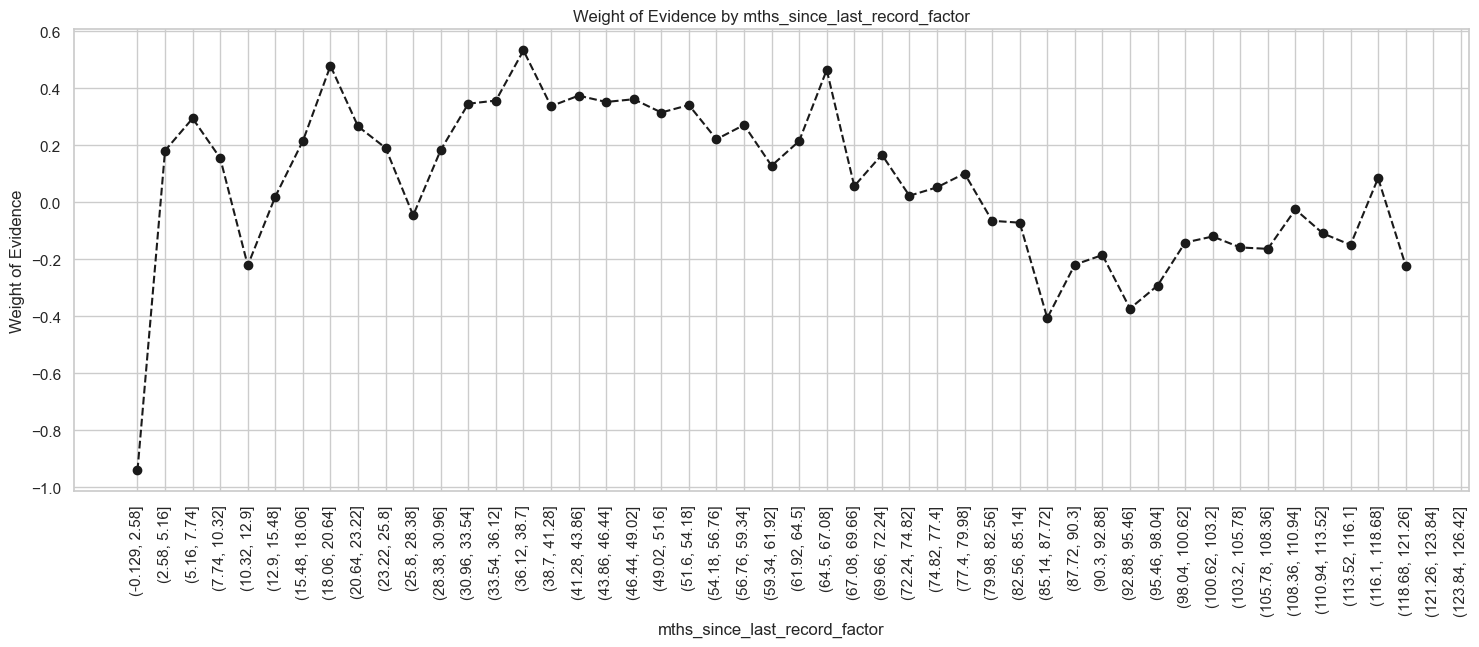

In [131]:
plot_by_woe(df_temp, 90)
# We plot the weight of evidence values.

In [132]:
# Categories: 'Missing', '0-2', '3-20', '21-31', '32-80', '81-86', '>86'
df_inputs_prepr['mths_since_last_record:Missing'] = np.where((df_inputs_prepr['mths_since_last_record'].isnull()), 1, 0)
df_inputs_prepr['mths_since_last_record:0-2'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 0) & (df_inputs_prepr['mths_since_last_record'] <= 2), 1, 0)
df_inputs_prepr['mths_since_last_record:3-20'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 3) & (df_inputs_prepr['mths_since_last_record'] <= 20), 1, 0)
df_inputs_prepr['mths_since_last_record:21-31'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 21) & (df_inputs_prepr['mths_since_last_record'] <= 31), 1, 0)
df_inputs_prepr['mths_since_last_record:32-80'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 32) & (df_inputs_prepr['mths_since_last_record'] <= 80), 1, 0)
df_inputs_prepr['mths_since_last_record:81-86'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 81) & (df_inputs_prepr['mths_since_last_record'] <= 86), 1, 0)
df_inputs_prepr['mths_since_last_record:>86'] = np.where((df_inputs_prepr['mths_since_last_record'] > 86), 1, 0)

C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\1059239224.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_record:Missing'] = np.where((df_inputs_prepr['mths_since_last_record'].isnull()), 1, 0)
C:\Users\lkima\AppData\Local\Temp\ipykernel_38528\1059239224.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_record:0-2'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 0) & (df_inputs_prepr['mths_since_last_record'] <= 2), 1, 0)
C:\Users\lkima\AppData\

#### Preprocessing the test dataset

In [133]:
loan_data_inputs_train = df_inputs_prepr #Save Preprocessed Train Data

# loan_data_inputs_test = df_inputs_prepr #Save Preprocessed Test Data

In [134]:
loan_data_inputs_train.to_csv('loan_data_inputs_train.csv')


In [135]:
loan_data_targets_train.to_csv('loan_data_targets_train.csv')


In [136]:
# loan_data_inputs_test.to_csv('loan_data_inputs_test.csv')


In [137]:
# loan_data_targets_test.to_csv('loan_data_targets_test.csv')